In [29]:
import pandas as pd

df1 = pd.read_csv('2015-2025_california.csv')
df2 = pd.read_csv('2005-2015_california.csv')

df = pd.concat([df1, df2], ignore_index=True)

# Plot distributions of uncertainties
Plot histograms of magError, horizontalError, depthError, gap, and rms.

WHY: This helps identify typical measurement quality and detect extreme outliers or poorly constrained events.


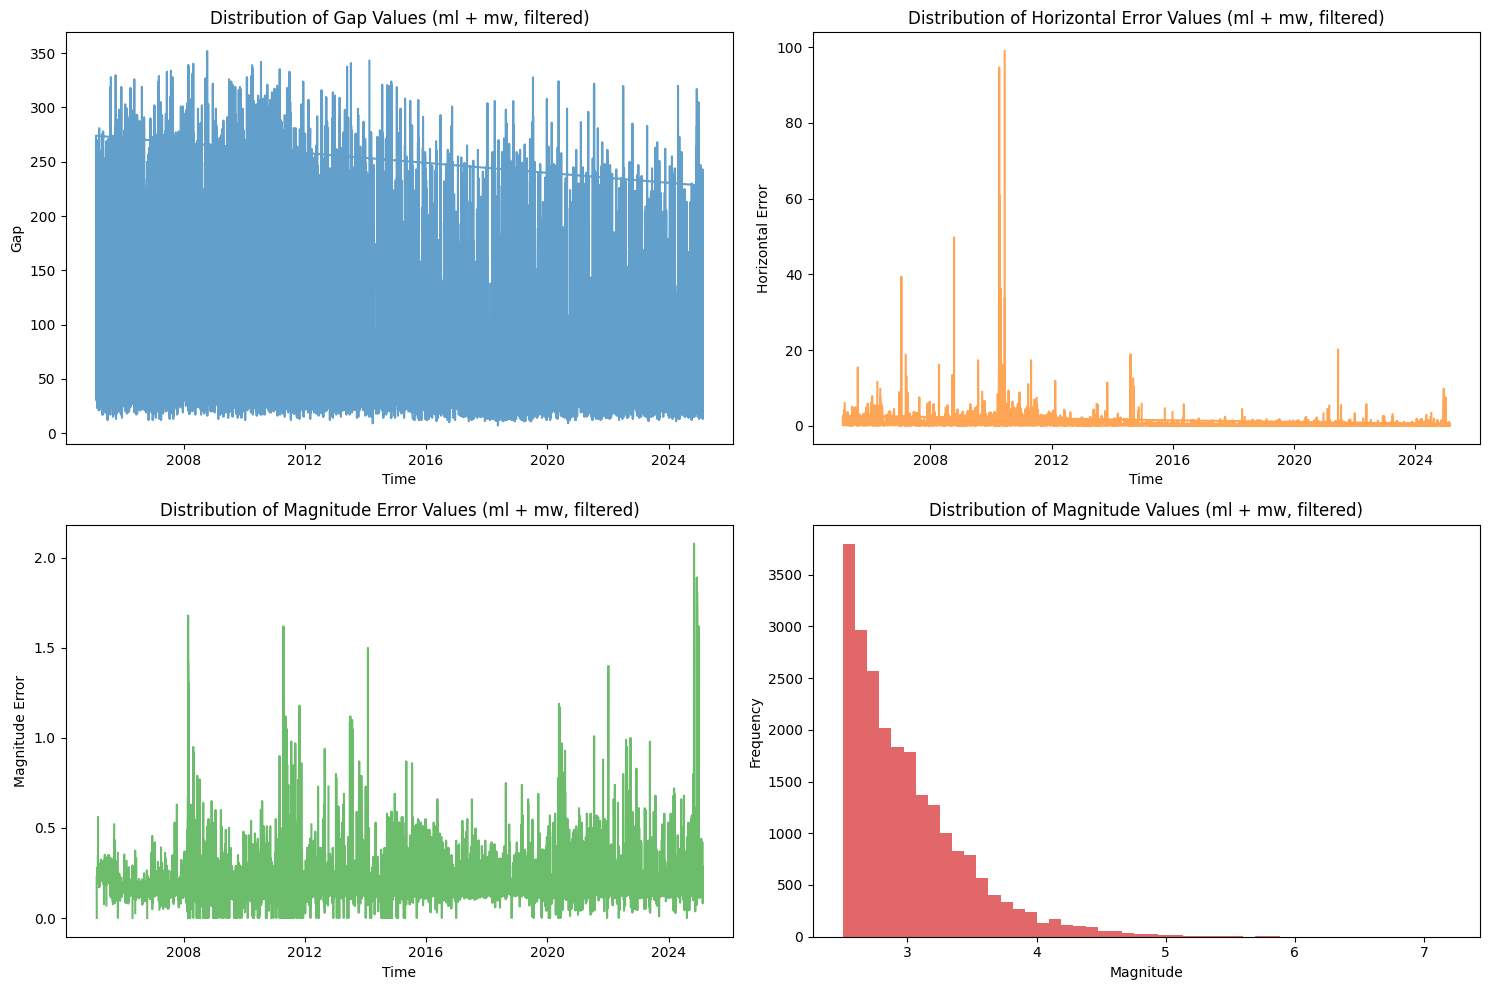

In [30]:
df_sub_ml = df[df['magType'] == 'ml']
df_sub_mw = df[df['magType'] == 'mw']
df_sub_md = df[df['magType'] == 'md']

# Merge ml and mw subframes using pd.concat()
df_select = pd.concat([df_sub_ml, df_sub_mw], ignore_index=True)
df_select['time'] = pd.to_datetime(df_select['time'])

import matplotlib.pyplot as plt

# Plot gap, horizontalError, and magError in a 1x3 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gap histogram
axes[0, 0].plot(df_select['time'], df_select['gap'], color='C0', alpha=0.7)
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Gap')
axes[0, 0].set_title('Distribution of Gap Values (ml + mw, filtered)')

# HorizontalError histogram
axes[0, 1].plot(df_select['time'], df_select['horizontalError'], color='C1', alpha=0.7)
axes[0, 1].set_ylabel('Horizontal Error')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_title('Distribution of Horizontal Error Values (ml + mw, filtered)')

# MagError histogram
axes[1, 0].plot(df_select['time'], df_select['magError'], color='C2', alpha=0.7)
axes[1, 0].set_ylabel('Magnitude Error')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_title('Distribution of Magnitude Error Values (ml + mw, filtered)')

# Mag histogram
axes[1, 1].hist(df_select['mag'], bins=50, color='C3', alpha=0.7)
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_xlabel('Magnitude')
axes[1, 1].set_title('Distribution of Magnitude Values (ml + mw, filtered)')

plt.tight_layout()
plt.show()

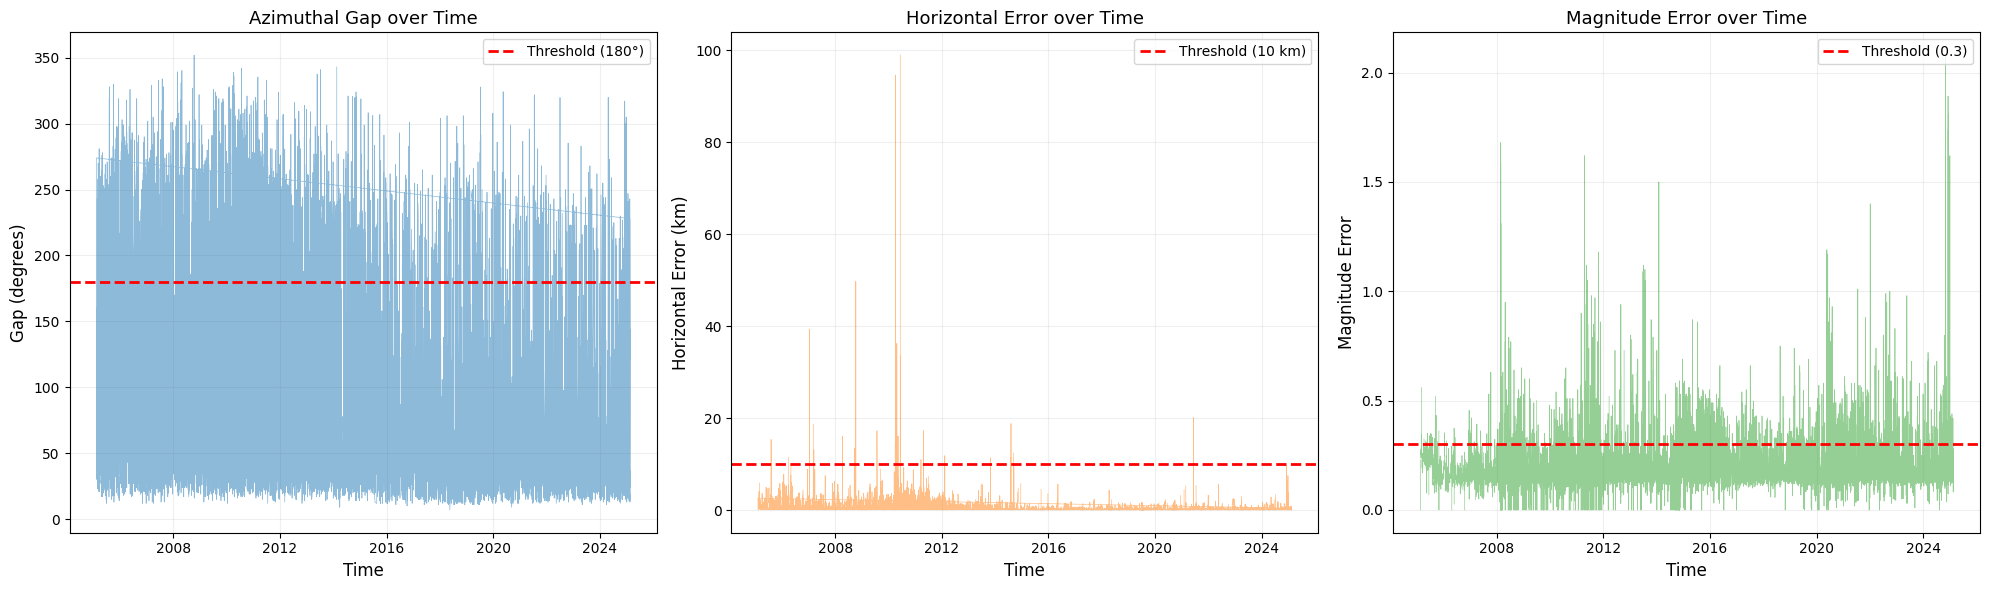

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Filtering logic (ensure types and datetime are handled)
df_sub_ml = df[df['magType'] == 'ml']
df_sub_mw = df[df['magType'] == 'mw']
df_select = pd.concat([df_sub_ml, df_sub_mw], ignore_index=True)
df_select['time'] = pd.to_datetime(df_select['time'])

# 1. Create a 1x3 subplot layout (omitting the last histogram)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Gap vs Time ---
axes[0].plot(df_select['time'], df_select['gap'], color='C0', alpha=0.5, linewidth=0.5)
# Draw the threshold line at 180 degrees
axes[0].axhline(y=180, color='red', linestyle='--', linewidth=2, label='Threshold (180°)')
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('Gap (degrees)', fontsize=12)
axes[0].set_title('Azimuthal Gap over Time', fontsize=13)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.2)

# --- Plot 2: Horizontal Error vs Time ---
axes[1].plot(df_select['time'], df_select['horizontalError'], color='C1', alpha=0.5, linewidth=0.5)
# Draw the threshold line at 10 km
axes[1].axhline(y=10, color='red', linestyle='--', linewidth=2, label='Threshold (10 km)')
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Horizontal Error (km)', fontsize=12)
axes[1].set_title('Horizontal Error over Time', fontsize=13)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.2)

# --- Plot 3: Magnitude Error vs Time ---
axes[2].plot(df_select['time'], df_select['magError'], color='C2', alpha=0.5, linewidth=0.5)
# Draw the threshold line at 0.3 Magnitude units
axes[2].axhline(y=0.3, color='red', linestyle='--', linewidth=2, label='Threshold (0.3)')
axes[2].set_xlabel('Time', fontsize=12)
axes[2].set_ylabel('Magnitude Error', fontsize=12)
axes[2].set_title('Magnitude Error over Time', fontsize=13)
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('california_earthquake_quality_metrics.png', dpi=300)
plt.show()

# Filter unreliable data
Example filters:
magError < 0.3
horizontalError < 10 km
gap < 180 degrees

WHY: Events with large uncertainties can distort statistical relationships and produce misleading results.


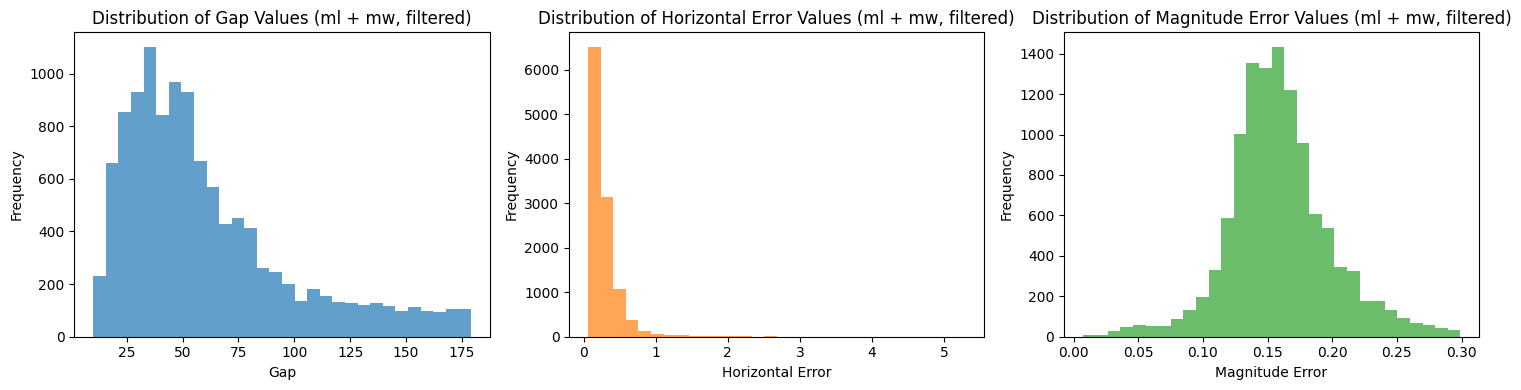

In [32]:
df_sub_ml = df[df['magType'] == 'ml']
df_sub_mw = df[df['magType'] == 'mw']
df_sub_md = df[df['magType'] == 'md']

# Merge ml and mw subframes using pd.concat()
df_select = pd.concat([df_sub_ml, df_sub_mw], ignore_index=True)
df_select['time'] = pd.to_datetime(df_select['time'])

# Filter by gap < 250, horizontalError < 10, and magError < 0.75
df_select = df_select[
    (df_select['gap'] < 180) &
    (df_select['horizontalError'] < 10) &
    (df_select['magError'] < 0.3)
]

import matplotlib.pyplot as plt

# Plot gap, horizontalError, and magError in a 1x3 subplot layout
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gap histogram
axes[0].hist(df_select['gap'].dropna(), bins=30, color='C0', alpha=0.7)
axes[0].set_xlabel('Gap')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Gap Values (ml + mw, filtered)')

# HorizontalError histogram
axes[1].hist(df_select['horizontalError'].dropna(), bins=30, color='C1', alpha=0.7)
axes[1].set_xlabel('Horizontal Error')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Horizontal Error Values (ml + mw, filtered)')

# MagError histogram
axes[2].hist(df_select['magError'].dropna(), bins=30, color='C2', alpha=0.7)
axes[2].set_xlabel('Magnitude Error')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Magnitude Error Values (ml + mw, filtered)')

plt.tight_layout()
plt.show()

In [33]:
len(df_select[df_select['mag'] >= 4.0])

131

# Report dataset size before and after filtering
Count the number of earthquakes before filtering and after filtering.

WHY: This shows how much data quality filtering affects the dataset and ensures transparency in analysis.


In [34]:
len(df), len(df_select)

(30834, 11467)

# Compute mean magnitude and depth with uncertainty in the mean
Calculate the average magnitude and depth. The uncertainty in the mean is:

σ_mean = σ / sqrt(N)

where σ is the standard deviation and N is the number of earthquakes.

WHY: This quantifies how precisely we know the typical magnitude and depth of earthquakes in the dataset.


In [35]:
# Compute mean magnitude and depth with uncertainty (standard error in mean)
import numpy as np

# Calculate statistics
mean_magnitude = df_select['mag'].mean()
std_magnitude = df_select['mag'].std()
n_magnitude = df_select['mag'].count()
se_magnitude = std_magnitude / np.sqrt(n_magnitude)  # Standard error in mean

mean_depth = df_select['depth'].mean()
std_depth = df_select['depth'].std()
n_depth = df_select['depth'].count()
se_depth = std_depth / np.sqrt(n_depth)  # Standard error in mean

# Display results
print("=" * 60)
print("MAGNITUDE Statistics (filtered data: ml + mw)")
print("=" * 60)
print(f"Mean Magnitude: {mean_magnitude:.4f}")
print(f"Std Dev: {std_magnitude:.4f}")
print(f"Count: {n_magnitude}")
print(f"Standard Error (Uncertainty in Mean): {se_magnitude:.4f}")
print()
print("=" * 60)
print("DEPTH Statistics (filtered data: ml + mw)")
print("=" * 60)
print(f"Mean Depth: {mean_depth:.4f} km")
print(f"Std Dev: {std_depth:.4f} km")
print(f"Count: {n_depth}")
print(f"Standard Error (Uncertainty in Mean): {se_depth:.4f} km")
print("=" * 60)

# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Quantity': ['Magnitude', 'Depth (km)'],
    'Mean': [mean_magnitude, mean_depth],
    'Std Dev': [std_magnitude, std_depth],
    'Count': [n_magnitude, n_depth],
    'Std Error (Uncertainty)': [se_magnitude, se_depth]
})

print("\nSummary Table:")
print(summary_df.to_string(index=False))


MAGNITUDE Statistics (filtered data: ml + mw)
Mean Magnitude: 2.9195
Std Dev: 0.3495
Count: 11467
Standard Error (Uncertainty in Mean): 0.0033

DEPTH Statistics (filtered data: ml + mw)
Mean Depth: 6.9596 km
Std Dev: 4.9850 km
Count: 11467
Standard Error (Uncertainty in Mean): 0.0466 km

Summary Table:
  Quantity     Mean  Std Dev  Count  Std Error (Uncertainty)
 Magnitude 2.919528 0.349486  11467                 0.003264
Depth (km) 6.959633 4.984953  11467                 0.046552


# Poisson uncertainty for earthquake rates
Earthquake counts follow Poisson statistics because earthquakes occur as discrete random events.

Uncertainty in event counts:
σ = sqrt(N)

WHY: When computing earthquake rates (events per month), the statistical uncertainty must be included.


In [36]:
# Poisson Fit Analysis for Earthquake Rates
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import factorial

print("\n" + "="*70)
print("POISSON DISTRIBUTION FIT TO EARTHQUAKE COUNTS")
print("="*70)

# Ensure time is datetime and filter data
df_select['time'] = pd.to_datetime(df_select['time'])

# Bin earthquakes by month
df_select['year_month'] = df_select['time'].dt.to_period('M')
monthly_counts = df_select.groupby('year_month').size().reset_index(name='count')

# Convert period to timestamp for plotting
monthly_counts['date'] = monthly_counts['year_month'].dt.to_timestamp()

# Get the observed counts
observed_counts = monthly_counts['count'].values

print(f"\nObserved Data Statistics:")
print(f"  Total months: {len(observed_counts)}")
print(f"  Total earthquakes: {observed_counts.sum()}")
print(f"  Mean rate λ (earthquakes/month): {observed_counts.mean():.4f}")
print(f"  Std Dev of monthly counts: {observed_counts.std():.4f}")
print(f"  Min monthly count: {observed_counts.min()}")
print(f"  Max monthly count: {observed_counts.max()}")

# FIT: Estimate lambda (mean) from the data
lambda_fit = observed_counts.mean()

print(f"\n{'Poisson Fit Parameter:':.<50}")
print(f"  λ (expected rate) = {lambda_fit:.4f} earthquakes/month")

# Calculate theoretical Poisson uncertainties
# For Poisson distribution: variance = λ, so σ = √λ
poisson_sigma = np.sqrt(lambda_fit)
print(f"\n{'Theoretical Poisson Uncertainty:':.<50}")
print(f"  σ_theoretical = √λ = √{lambda_fit:.4f} = {poisson_sigma:.4f}")

# Calculate observed uncertainties (std dev of counts)
observed_sigma = observed_counts.std()
print(f"\n{'Observed Uncertainty:':.<50}")
print(f"  σ_observed = {observed_sigma:.4f}")

# Compare observed vs theoretical
print(f"\n{'Comparison:':.<50}")
print(f"  Ratio (observed/theoretical) = {observed_sigma/poisson_sigma:.4f}")
print(f"  Observed variance = {observed_counts.var():.4f}")
print(f"  Theoretical variance (λ) = {lambda_fit:.4f}")

# Goodness of fit: Chi-square test
# Create bins for observed distribution
count_range = np.arange(0, observed_counts.max() + 2)
observed_hist, _ = np.histogram(observed_counts, bins=count_range)

# Calculate theoretical Poisson probabilities
theoretical_probs = []
for k in count_range[:-1]:
    prob = (lambda_fit**k * np.exp(-lambda_fit)) / factorial(k)
    theoretical_probs.append(prob)

theoretical_hist = np.array(theoretical_probs) * len(observed_counts)

# Chi-square test (only for bins with expected frequency > 5)
valid_indices = theoretical_hist >= 5
if valid_indices.sum() > 1:
    chi2_stat = np.sum((observed_hist[valid_indices] - theoretical_hist[valid_indices])**2 /
                       theoretical_hist[valid_indices])
    df_chi = valid_indices.sum() - 2  # df = bins - 1 - 1 (for fitting lambda)
    p_value = 1 - stats.chi2.cdf(chi2_stat, df_chi)
    print(f"\n{'Chi-square Goodness of Fit:':.<50}")
    print(f"  χ² statistic = {chi2_stat:.4f}")
    print(f"  degrees of freedom = {df_chi}")
    print(f"  p-value = {p_value:.4f}")
    if p_value > 0.05:
        print(f"  ✓ Data is consistent with Poisson (p > 0.05)")
    else:
        print(f"  ✗ Data deviates from Poisson (p < 0.05)")

print("\n" + "="*70 + "\n")


POISSON DISTRIBUTION FIT TO EARTHQUAKE COUNTS

Observed Data Statistics:
  Total months: 241
  Total earthquakes: 11467
  Mean rate λ (earthquakes/month): 47.5809
  Std Dev of monthly counts: 135.2916
  Min monthly count: 6
  Max monthly count: 2044

Poisson Fit Parameter:............................
  λ (expected rate) = 47.5809 earthquakes/month

Theoretical Poisson Uncertainty:..................
  σ_theoretical = √λ = √47.5809 = 6.8979

Observed Uncertainty:.............................
  σ_observed = 135.2916

Comparison:.......................................
  Ratio (observed/theoretical) = 19.6135
  Observed variance = 18303.8119
  Theoretical variance (λ) = 47.5809

Chi-square Goodness of Fit:.......................
  χ² statistic = 145.2847
  degrees of freedom = 18
  p-value = 0.0000
  ✗ Data deviates from Poisson (p < 0.05)




/tmp/ipykernel_8265/312833286.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_select['year_month'] = df_select['time'].dt.to_period('M')
/tmp/ipykernel_8265/312833286.py:64: RuntimeWarning: overflow encountered in scalar power
  prob = (lambda_fit**k * np.exp(-lambda_fit)) / factorial(k)
/tmp/ipykernel_8265/312833286.py:64: RuntimeWarning: invalid value encountered in scalar divide
  prob = (lambda_fit**k * np.exp(-lambda_fit)) / factorial(k)


/tmp/ipykernel_8265/4028285493.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_select['year_month'] = df_select['time'].dt.to_period('M')


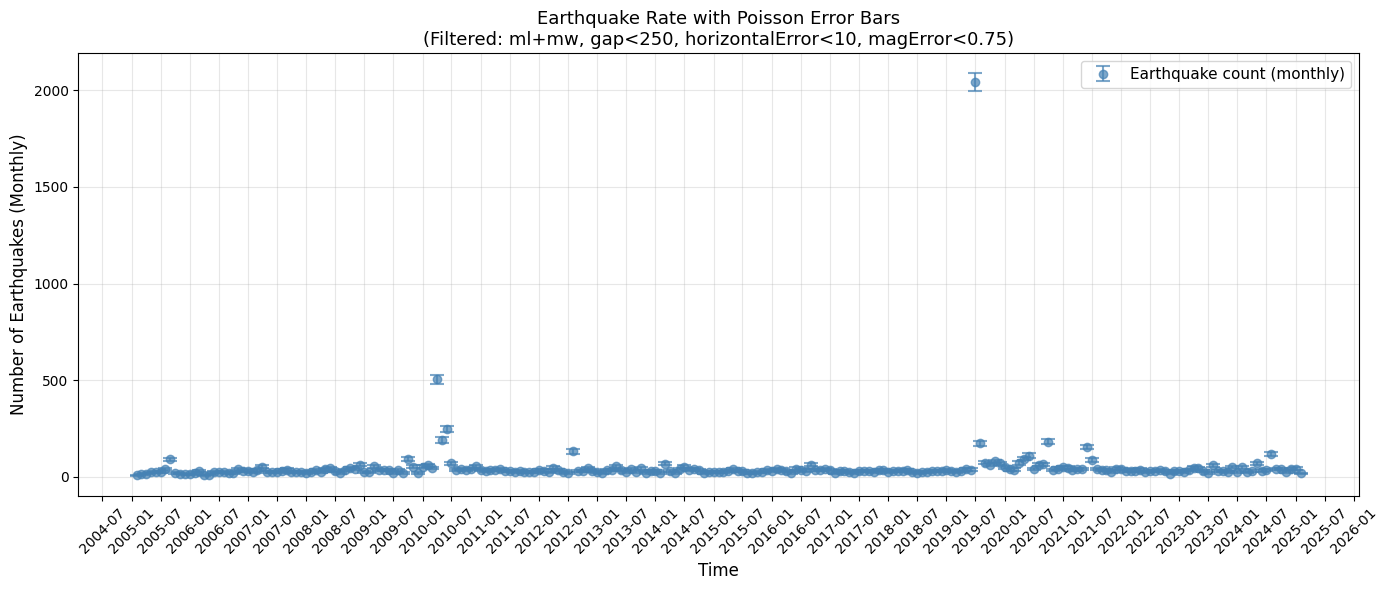

EARTHQUAKE RATE STATISTICS (Monthly Binning)
Total months: 241
Total earthquakes: 11467
Mean rate (earthquakes/month): 47.58
Std Dev of monthly counts: 135.57
Min monthly count: 6
Max monthly count: 2044


In [37]:
# Plot earthquake rate with Poisson error bars
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure time is datetime
df_select['time'] = pd.to_datetime(df_select['time'])

# Bin earthquakes by month (30 days approximately)
df_select['year_month'] = df_select['time'].dt.to_period('M')

# Count earthquakes per month
rate_data = df_select.groupby('year_month').size().reset_index(name='count')

# Convert period to timestamp for plotting
rate_data['date'] = rate_data['year_month'].dt.to_timestamp()

# Calculate Poisson errors: sqrt(count) for count data
rate_data['error'] = np.sqrt(rate_data['count'])

# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))

# Plot with error bars
ax.errorbar(rate_data['date'], rate_data['count'],
            yerr=rate_data['error'],
            fmt='o',
            markersize=6,
            capsize=5,
            capthick=1.5,
            elinewidth=1.5,
            color='steelblue',
            ecolor='steelblue',
            alpha=0.7,
            label='Earthquake count (monthly)')

# Formatting
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Number of Earthquakes (Monthly)', fontsize=12)
ax.set_title('Earthquake Rate with Poisson Error Bars\n(Filtered: ml+mw, gap<250, horizontalError<10, magError<0.75)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Format x-axis to show dates nicely
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('earthquake_rate_poisson.png', dpi=300)
plt.show()

# Summary statistics
print("=" * 60)
print("EARTHQUAKE RATE STATISTICS (Monthly Binning)")
print("=" * 60)
print(f"Total months: {len(rate_data)}")
print(f"Total earthquakes: {rate_data['count'].sum()}")
print(f"Mean rate (earthquakes/month): {rate_data['count'].mean():.2f}")
print(f"Std Dev of monthly counts: {rate_data['count'].std():.2f}")
print(f"Min monthly count: {rate_data['count'].min()}")
print(f"Max monthly count: {rate_data['count'].max()}")
print("=" * 60)


/tmp/ipykernel_8265/2423699102.py:41: RuntimeWarning: overflow encountered in scalar power
  prob = (lambda_fit**k * np.exp(-lambda_fit)) / factorial(k)
/tmp/ipykernel_8265/2423699102.py:41: RuntimeWarning: invalid value encountered in scalar divide
  prob = (lambda_fit**k * np.exp(-lambda_fit)) / factorial(k)


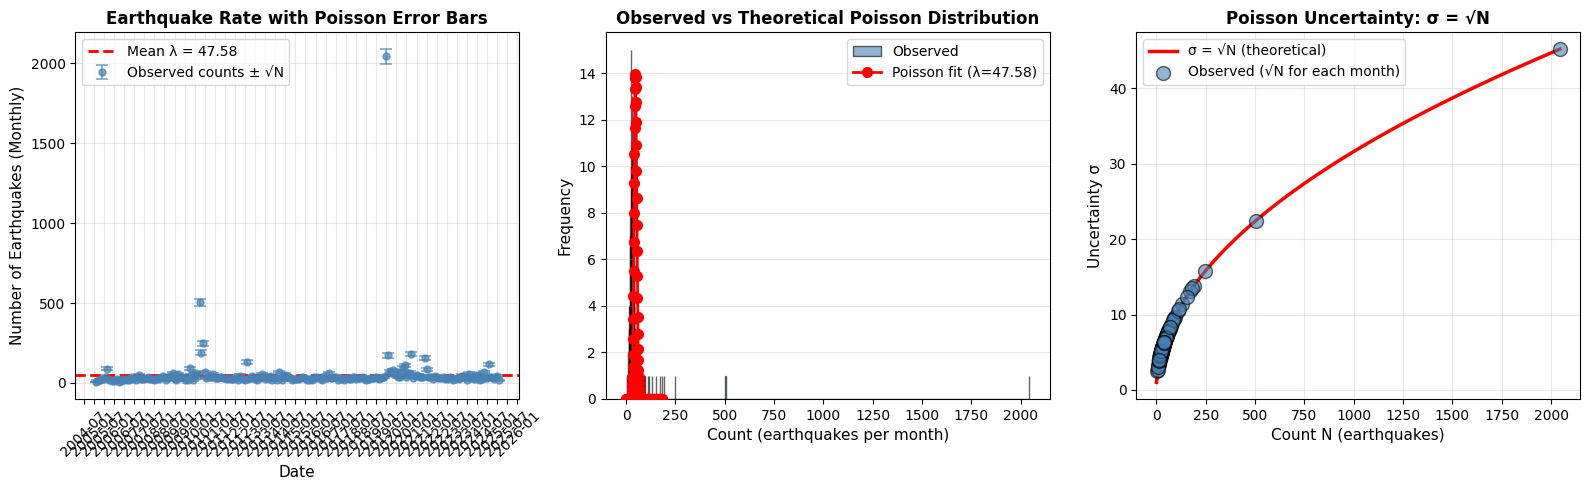


Key Insight: For Poisson-distributed events, the uncertainty in count N is σ = √N
This means relative uncertainty σ/N = 1/√N decreases with larger counts.


In [38]:
# Visualization: Compare Observed vs Poisson Distribution
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ===== Plot 1: Time series with error bars =====
ax = axes[0]
ax.errorbar(monthly_counts['date'], monthly_counts['count'],
            yerr=np.sqrt(monthly_counts['count']),  # Poisson errors: √N
            fmt='o',
            markersize=5,
            capsize=4,
            capthick=1.2,
            elinewidth=1.2,
            color='steelblue',
            ecolor='steelblue',
            alpha=0.7,
            label='Observed counts ± √N')

ax.axhline(lambda_fit, color='red', linestyle='--', linewidth=2, label=f'Mean λ = {lambda_fit:.2f}')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Number of Earthquakes (Monthly)', fontsize=11)
ax.set_title('Earthquake Rate with Poisson Error Bars', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# ===== Plot 2: Histogram - Observed vs Theoretical Poisson =====
ax = axes[1]
count_range = np.arange(0, observed_counts.max() + 1)
ax.hist(observed_counts, bins=count_range, alpha=0.6, label='Observed', color='steelblue', edgecolor='black')

# Overlay theoretical Poisson distribution
theoretical_probs = []
for k in count_range:
    prob = (lambda_fit**k * np.exp(-lambda_fit)) / factorial(k)
    theoretical_probs.append(prob)

theoretical_counts = np.array(theoretical_probs) * len(observed_counts)
ax.plot(count_range, theoretical_counts, 'o-', color='red', linewidth=2,
        markersize=7, label=f'Poisson fit (λ={lambda_fit:.2f})', zorder=5)

ax.set_xlabel('Count (earthquakes per month)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Observed vs Theoretical Poisson Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# ===== Plot 3: Uncertainty demonstration σ = √N =====
ax = axes[2]

# Show that uncertainty scales as sqrt(N)
N_range = np.linspace(1, observed_counts.max(), 100)
sigma_predicted = np.sqrt(N_range)

# Plot the relationship
ax.plot(N_range, sigma_predicted, 'r-', linewidth=2.5, label='σ = √N (theoretical)')

# Overlay observed data
ax.scatter(observed_counts, np.sqrt(observed_counts),
          s=100, alpha=0.6, color='steelblue', edgecolor='black', linewidth=1,
          label='Observed (√N for each month)', zorder=5)

ax.set_xlabel('Count N (earthquakes)', fontsize=11)
ax.set_ylabel('Uncertainty σ', fontsize=11)
ax.set_title('Poisson Uncertainty: σ = √N', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insight: For Poisson-distributed events, the uncertainty in count N is σ = √N")
print("This means relative uncertainty σ/N = 1/√N decreases with larger counts.")

# Plot event rates with error bars
Plot number of earthquakes per time interval (e.g., monthly). Include error bars using sqrt(N).


/tmp/ipykernel_8265/456175928.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select_prime['time'] = pd.to_datetime(df_select_prime['time'])
/tmp/ipykernel_8265/456175928.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_select_prime['year_month'] = df_select_prime['time'].dt.to_period('M')
/tmp/ipykernel_8265/456175928.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select_prime['year_month'] = df_select_prime['time'].dt.to_period('M')


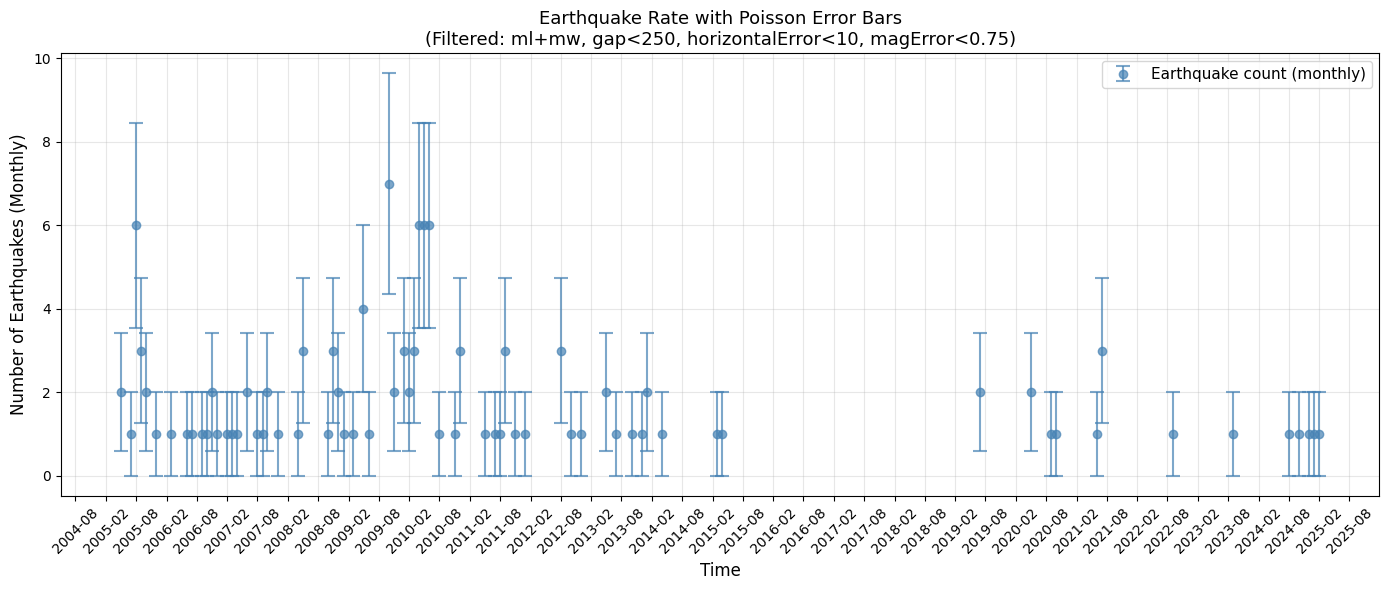

EARTHQUAKE RATE STATISTICS (Monthly Binning)
Total months: 71
Total earthquakes: 130
Mean rate (earthquakes/month): 1.83
Std Dev of monthly counts: 1.43
Min monthly count: 1
Max monthly count: 7


In [39]:
# Plot earthquake rate with Poisson error bars
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure time is datetime
df_select_prime = df_select[df_select['mag'] > 4]
df_select_prime['time'] = pd.to_datetime(df_select_prime['time'])

# Bin earthquakes by month (30 days approximately)
df_select_prime['year_month'] = df_select_prime['time'].dt.to_period('M')

# Count earthquakes per month
rate_data = df_select_prime.groupby('year_month').size().reset_index(name='count')

# Convert period to timestamp for plotting
rate_data['date'] = rate_data['year_month'].dt.to_timestamp()

# Calculate Poisson errors: sqrt(count) for count data
rate_data['error'] = np.sqrt(rate_data['count'])

# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))

# Plot with error bars
ax.errorbar(rate_data['date'], rate_data['count'],
            yerr=rate_data['error'],
            fmt='o',
            markersize=6,
            capsize=5,
            capthick=1.5,
            elinewidth=1.5,
            color='steelblue',
            ecolor='steelblue',
            alpha=0.7,
            label='Earthquake count (monthly)')

# Formatting
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Number of Earthquakes (Monthly)', fontsize=12)
ax.set_title('Earthquake Rate with Poisson Error Bars\n(Filtered: ml+mw, gap<250, horizontalError<10, magError<0.75)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Format x-axis to show dates nicely
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics
print("=" * 60)
print("EARTHQUAKE RATE STATISTICS (Monthly Binning)")
print("=" * 60)
print(f"Total months: {len(rate_data)}")
print(f"Total earthquakes: {rate_data['count'].sum()}")
print(f"Mean rate (earthquakes/month): {rate_data['count'].mean():.2f}")
print(f"Std Dev of monthly counts: {rate_data['count'].std():.2f}")
print(f"Min monthly count: {rate_data['count'].min()}")
print(f"Max monthly count: {rate_data['count'].max()}")
print("=" * 60)


/tmp/ipykernel_8265/393211942.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mag_counts = df_select_copy.groupby('mag_bin').size().reset_index(name='count')


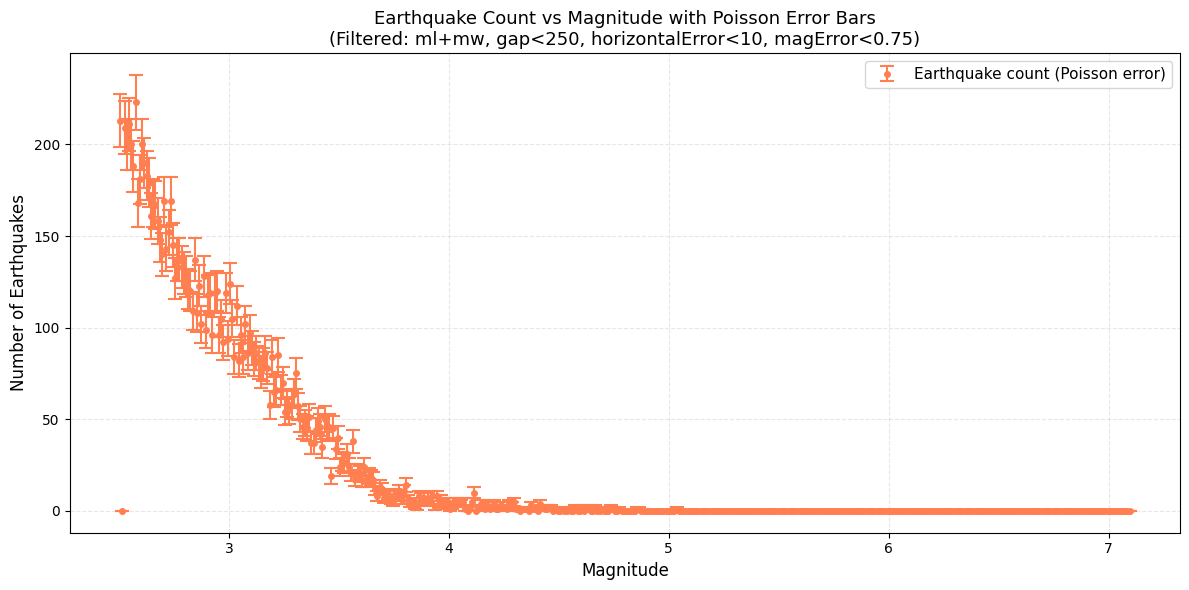

EARTHQUAKE COUNT BY MAGNITUDE STATISTICS
Magnitude range: 2.50 to 7.10
Total earthquakes: 11228
Number of magnitude bins: 460
Max count in a magnitude bin: 223
Min count in a magnitude bin: 0

Magnitude Bin Details:
Magnitude Range Magnitude Center  Count  Poisson Error
    (2.5, 2.51]            2.505    213      14.594520
   (2.51, 2.52]            2.515      0       0.000000
   (2.52, 2.53]            2.525    209      14.456832
   (2.53, 2.54]            2.535    200      14.142136
   (2.54, 2.55]            2.545    211      14.525839
   (2.55, 2.56]            2.555    200      14.142136
   (2.56, 2.57]            2.565    188      13.711309
   (2.57, 2.58]            2.575    223      14.933185
   (2.58, 2.59]            2.585    168      12.961481
    (2.59, 2.6]            2.595    181      13.453624
    (2.6, 2.61]            2.605    200      14.142136
   (2.61, 2.62]            2.615    190      13.784049
   (2.62, 2.63]            2.625    183      13.527749
   (2.63, 2.64

In [40]:
# Plot magnitude vs earthquake count with Poisson error bars
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bin earthquakes by magnitude (0.5 magnitude unit bins)
bin_width = 0.01
min_mag = np.floor(df_select['mag'].min() / bin_width) * bin_width
max_mag = np.ceil(df_select['mag'].max() / bin_width) * bin_width
bins = np.arange(min_mag, max_mag + bin_width, bin_width)

# Create magnitude bins and count earthquakes per bin
df_select_copy = df_select[df_select['mag'] >= 2.5]
df_select_copy['mag_bin'] = pd.cut(df_select_copy['mag'], bins=bins)


# Group by magnitude bin and count
mag_counts = df_select_copy.groupby('mag_bin').size().reset_index(name='count')

# Get bin centers for plotting
mag_counts['mag_center'] = mag_counts['mag_bin'].apply(lambda x: x.mid)

# Remove any NaN entries
mag_counts = mag_counts.dropna(subset=['mag_center'])

# Calculate Poisson errors: sqrt(count) for count data
mag_counts['error'] = np.sqrt(mag_counts['count'])
N = len(mag_counts['count'])
# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot with error bars
ax.errorbar(mag_counts['mag_center'], mag_counts['count'],
            yerr=mag_counts['error'],
            fmt='o',
            markersize=4,
            capsize=5,
            capthick=1.5,
            elinewidth=1.5,
            color='coral',
            ecolor='coral',
            alpha=1,
            label='Earthquake count (Poisson error)')

# Formatting
ax.set_xlabel('Magnitude', fontsize=12)
ax.set_ylabel('Number of Earthquakes', fontsize=12)
ax.set_title('Earthquake Count vs Magnitude with Poisson Error Bars\n(Filtered: ml+mw, gap<250, horizontalError<10, magError<0.75)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Summary statistics
print("=" * 70)
print("EARTHQUAKE COUNT BY MAGNITUDE STATISTICS")
print("=" * 70)
print(f"Magnitude range: {df_select['mag'].min():.2f} to {df_select['mag'].max():.2f}")
print(f"Total earthquakes: {mag_counts['count'].sum()}")
print(f"Number of magnitude bins: {len(mag_counts)}")
print(f"Max count in a magnitude bin: {mag_counts['count'].max()}")
print(f"Min count in a magnitude bin: {mag_counts['count'].min()}")
print("\nMagnitude Bin Details:")
print("=" * 70)
mag_counts_display = mag_counts[['mag_bin', 'mag_center', 'count', 'error']].copy()
mag_counts_display.columns = ['Magnitude Range', 'Magnitude Center', 'Count', 'Poisson Error']
print(mag_counts_display.to_string(index=False))
print("=" * 70)


# Magnitude histogram and power-law verification
Plot a histogram of earthquake magnitudes.

Earthquake magnitudes typically follow the Gutenberg–Richter power-law distribution:

log10 N(M) = a − bM

WHY: This confirms that the dataset follows known statistical laws of seismicity.


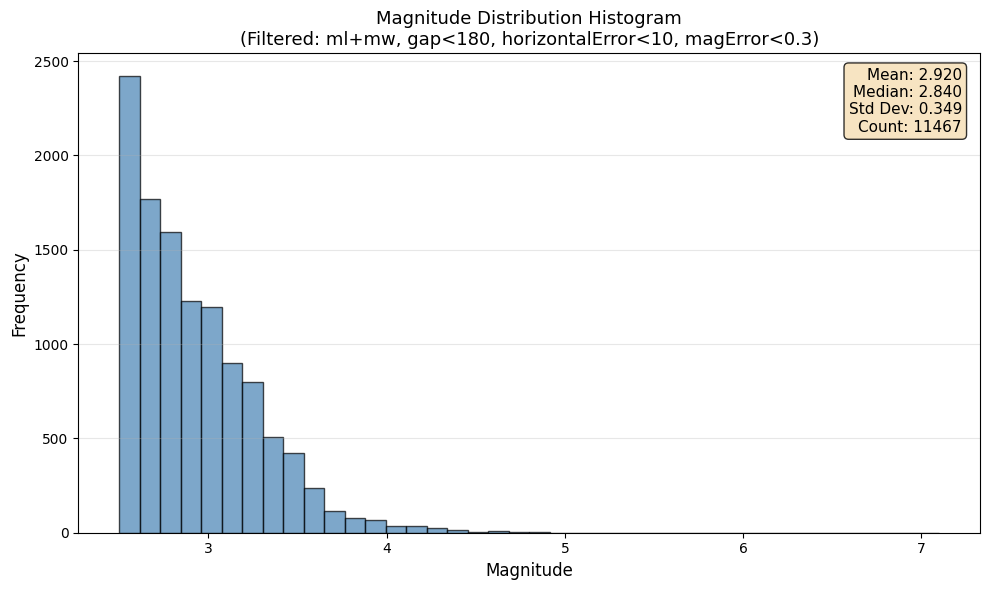

MAGNITUDE HISTOGRAM STATISTICS
Mean Magnitude: 2.9195
Median Magnitude: 2.8400
Std Dev: 0.3495
Min Magnitude: 2.5000
Max Magnitude: 7.1000
Total Count: 11467


In [41]:
# Plot magnitude histogram
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram
ax.hist(df_select['mag'].dropna(), bins=40, color='steelblue', alpha=0.7, edgecolor='black')

# Formatting
ax.set_xlabel('Magnitude', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Magnitude Distribution Histogram\n(Filtered: ml+mw, gap<180, horizontalError<10, magError<0.3)', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

# Add statistics to the plot
mean_mag = df_select['mag'].mean()
median_mag = df_select['mag'].median()
std_mag = df_select['mag'].std()

stats_text = f'Mean: {mean_mag:.3f}\nMedian: {median_mag:.3f}\nStd Dev: {std_mag:.3f}\nCount: {df_select["mag"].count()}'
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, fontsize=11, verticalalignment='top',
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# Print summary statistics
print("=" * 60)
print("MAGNITUDE HISTOGRAM STATISTICS")
print("=" * 60)
print(f"Mean Magnitude: {mean_mag:.4f}")
print(f"Median Magnitude: {median_mag:.4f}")
print(f"Std Dev: {std_mag:.4f}")
print(f"Min Magnitude: {df_select['mag'].min():.4f}")
print(f"Max Magnitude: {df_select['mag'].max():.4f}")
print(f"Total Count: {df_select['mag'].count()}")
print("=" * 60)


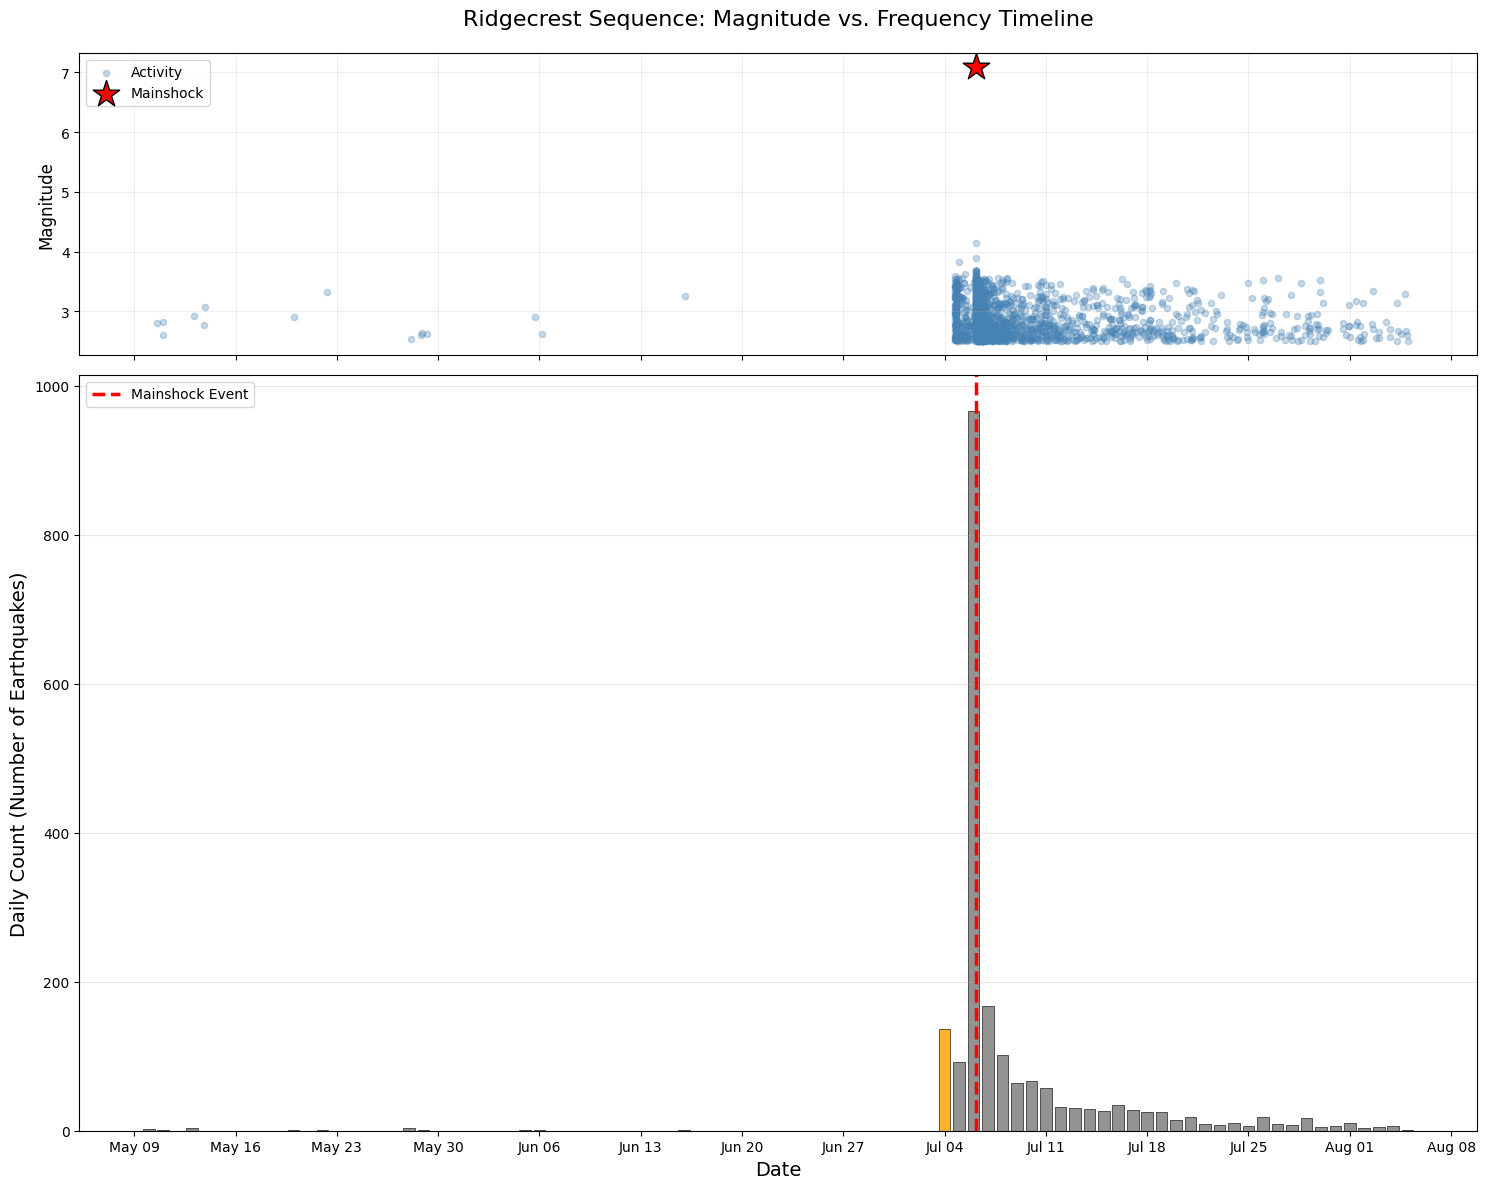

In [42]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_final_report_timeline(mainshock_row, df_full):
    # 1. Setup Data
    ms_time = mainshock_row['time']
    ms_mag = mainshock_row['mag']
    
    # Expanded spatial window to ensure the M6.4 is caught
    spatial_window = 0.8 
    
    start_date = ms_time - pd.Timedelta(days=60)
    end_date = ms_time + pd.Timedelta(days=30)
    
    # Apply filters
    df_window = df_full[
        (df_full['time'] >= start_date) & 
        (df_full['time'] <= end_date) &
        (df_full['latitude'].between(mainshock_row['latitude'] - spatial_window, mainshock_row['latitude'] + spatial_window)) &
        (df_full['longitude'].between(mainshock_row['longitude'] - spatial_window, mainshock_row['longitude'] + spatial_window))
    ].copy()

    # 2. Create Figure with INVERTED heights
    # Height ratios: 1 for Magnitude (Top), 2.5 for Daily Count (Bottom)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True, 
                                   gridspec_kw={'height_ratios': [1, 2.5]})

    # --- TOP PANEL: MAGNITUDE SCATTER (Smaller) ---
    ax1.scatter(df_window['time'], df_window['mag'], alpha=0.3, s=20, 
                color='steelblue', label='Activity')

    # DYNAMICALLY find and star significant events >= 6.0
    sig_events = df_window[df_window['mag'] >= 6.0]
    for _, event in sig_events.iterrows():
        if event['mag'] >= ms_mag - 0.1:
            ax1.scatter(event['time'], event['mag'], color='red', marker='*', s=400, 
                        edgecolor='black', zorder=10, label='Mainshock')
        else:
            # This WILL catch the M6.4 if it is in the dataset
            ax1.scatter(event['time'], event['mag'], color='gold', marker='*', s=250, 
                        edgecolor='black', zorder=9, label=f'Major Event (M{event["mag"]:.1f})')

    ax1.set_ylabel('Magnitude', fontsize=12)
    ax1.set_title('Ridgecrest Sequence: Magnitude vs. Frequency Timeline', fontsize=16, pad=20)
    ax1.grid(True, alpha=0.2)
    
    # Handle Legend duplicates
    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax1.legend(by_label.values(), by_label.keys(), loc='upper left')

    # --- BOTTOM PANEL: DAILY FREQUENCY (Larger) ---
    daily_counts = df_window.set_index('time').resample('D').size()
    
    # Highlight the peak activity day before the mainshock (The M6.4 swarm day)
    pre_ms_limit = ms_time.floor('D')
    pre_ms_counts = daily_counts[daily_counts.index < pre_ms_limit]
    
    if not pre_ms_counts.empty:
        peak_day = pre_ms_counts.idxmax()
        colors = ['orange' if d == peak_day else 'gray' for d in daily_counts.index]
    else:
        colors = 'gray'
    
    ax2.bar(daily_counts.index, daily_counts.values, color=colors, alpha=0.85, width=0.8, edgecolor='black', linewidth=0.5)
    ax2.axvline(ms_time, color='red', linestyle='--', linewidth=2.5, label='Mainshock Event')
    
    ax2.set_ylabel('Daily Count (Number of Earthquakes)', fontsize=14)
    ax2.set_xlabel('Date', fontsize=14)
    ax2.grid(True, axis='y', alpha=0.3)
    ax2.legend(loc='upper left')

    # Formatting X-Axis
    ax2.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.savefig('final_report_timeline.png', dpi=300)
    plt.show()

# Run for the largest event
main_event = df_select.loc[df_select['mag'].idxmax()]
plot_final_report_timeline(main_event, df_select)

Generating Seismic Timelines for the Top 4 Mainshocks...


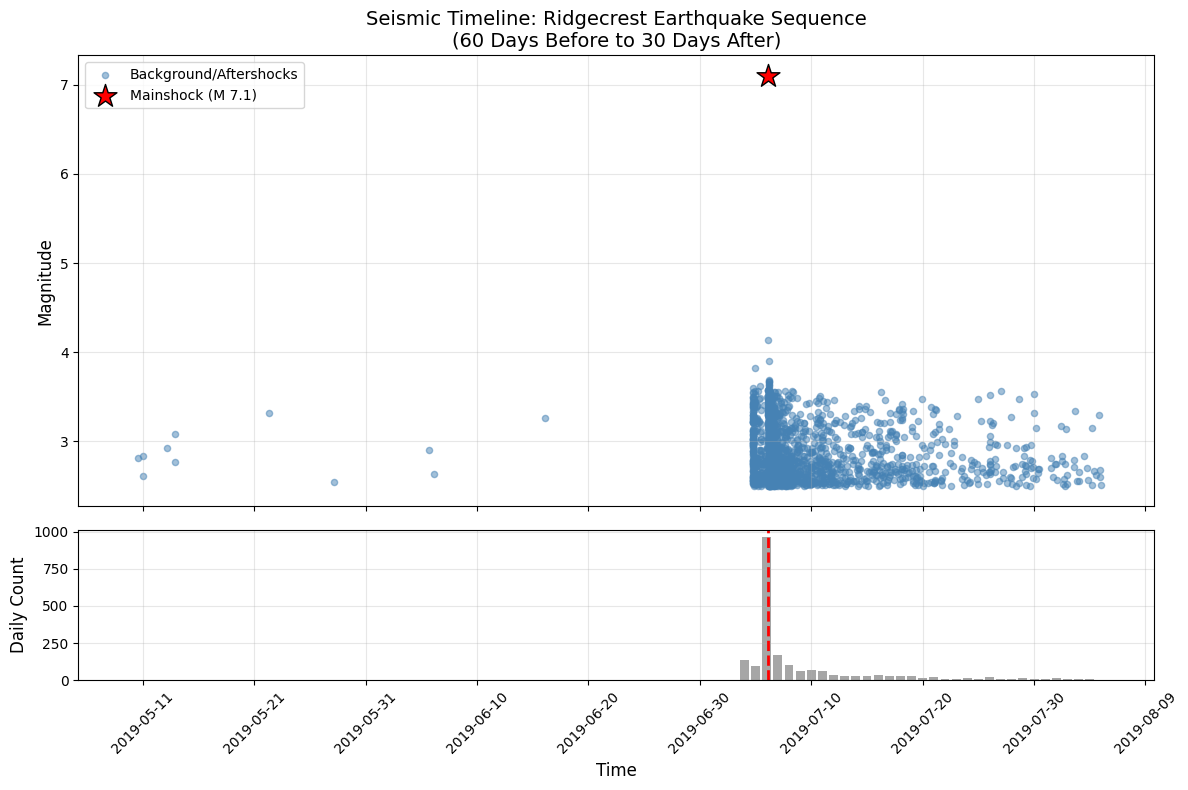

--------------------------------------------------------------------------------


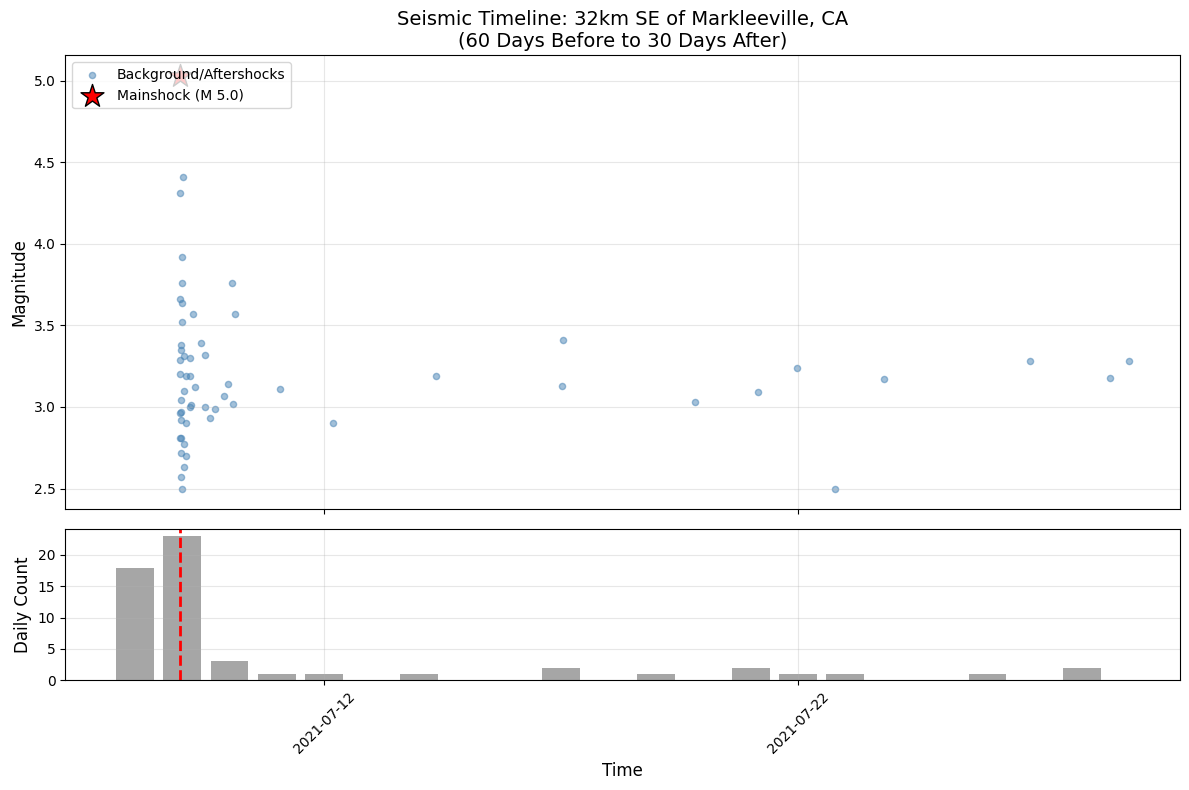

--------------------------------------------------------------------------------


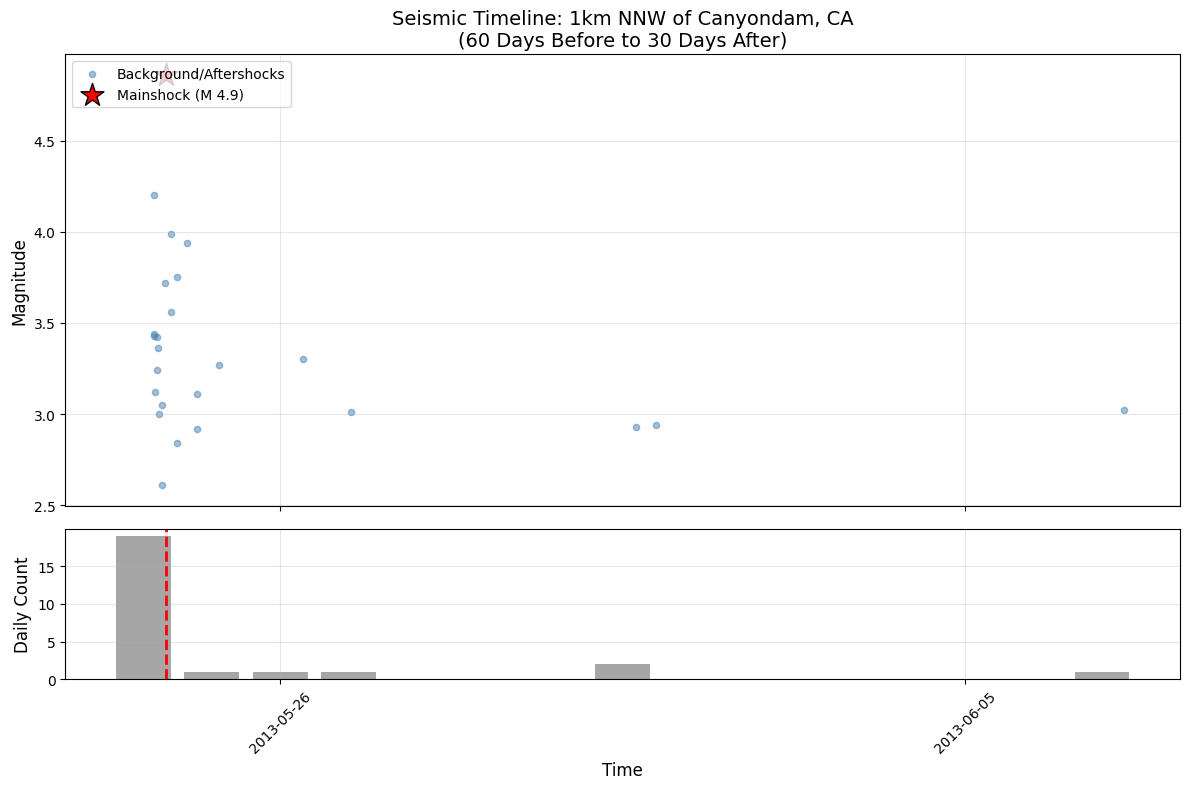

--------------------------------------------------------------------------------


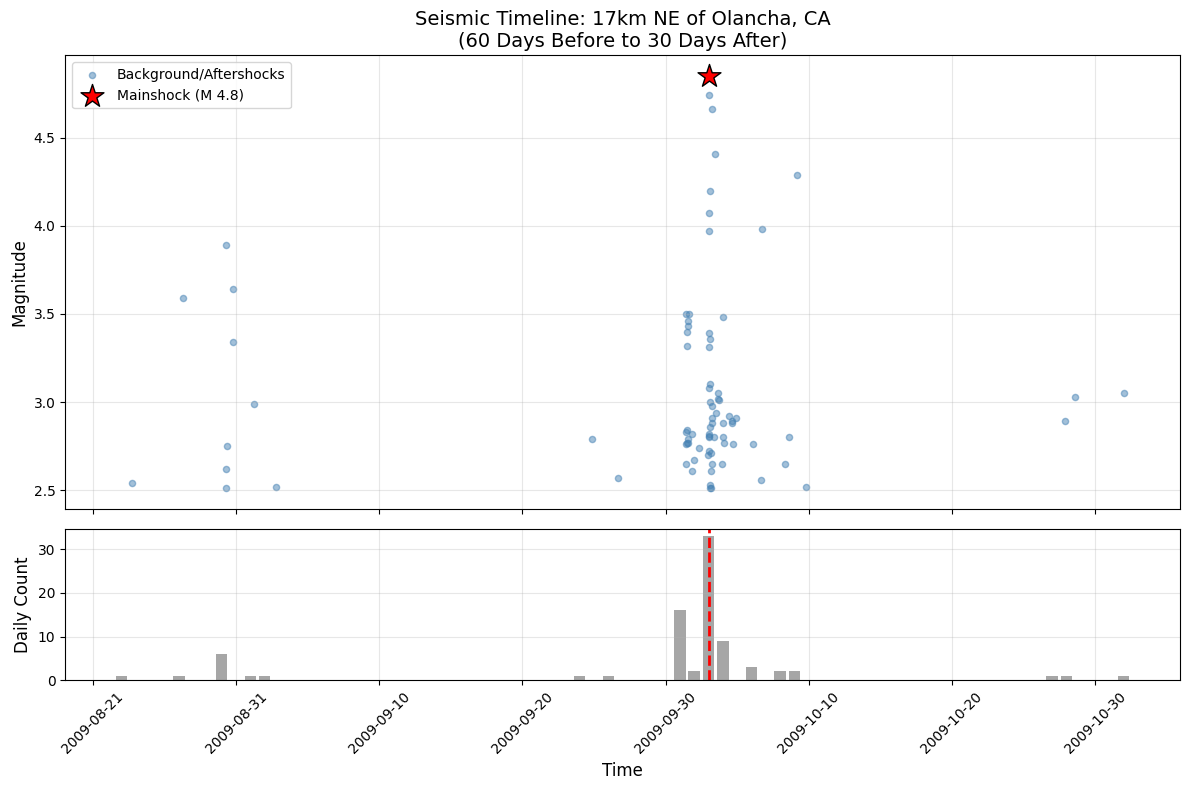

--------------------------------------------------------------------------------


In [43]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Ensure the time column is in the correct datetime format
df_select['time'] = pd.to_datetime(df_select['time'])

# Find the top 4 largest earthquakes in your filtered catalog
top_mainshocks = df_select.nlargest(4, 'mag')

def plot_seismic_timeline(mainshock_row, df_full, days_before=60, days_after=30, spatial_window=0.5):
    """
    Plots the timeline of seismic activity around a specific mainshock.
    spatial_window: +/- degrees of latitude/longitude to include (0.5 deg is ~55km)
    """
    ms_time = mainshock_row['time']
    ms_mag = mainshock_row['mag']
    ms_lat = mainshock_row['latitude']
    ms_lon = mainshock_row['longitude']
    ms_place = mainshock_row['place']
    
    start_date = ms_time - pd.Timedelta(days=days_before)
    end_date = ms_time + pd.Timedelta(days=days_after)
    
    # Filter the catalog for this specific time and area
    df_window = df_full[
        (df_full['time'] >= start_date) & 
        (df_full['time'] <= end_date) &
        (df_full['latitude'].between(ms_lat - spatial_window, ms_lat + spatial_window)) &
        (df_full['longitude'].between(ms_lon - spatial_window, ms_lon + spatial_window))
    ]
    
    # Create the 2-panel plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    
    # Top Plot: Timeline of Magnitude (Scatter)
    ax1.scatter(df_window['time'], df_window['mag'], alpha=0.5, s=20, color='steelblue', label='Background/Aftershocks')
    ax1.scatter(ms_time, ms_mag, color='red', marker='*', s=300, edgecolor='black', zorder=5, label=f'Mainshock (M {ms_mag:.1f})')
    ax1.set_ylabel('Magnitude', fontsize=12)
    ax1.set_title(f'Seismic Timeline: {ms_place}\n({days_before} Days Before to {days_after} Days After)', fontsize=14)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Bottom Plot: Daily Count (Density Bar Chart)
    daily_counts = df_window.set_index('time').resample('D').size()
    ax2.bar(daily_counts.index, daily_counts.values, color='gray', alpha=0.7, width=0.8)
    ax2.axvline(ms_time, color='red', linestyle='--', linewidth=2)
    ax2.set_ylabel('Daily Count', fontsize=12)
    ax2.set_xlabel('Time', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # Format the dates on the x-axis nicely
    ax2.xaxis.set_major_locator(mdates.DayLocator(interval=10))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    print("-" * 80)

# Generate the plots for the 4 largest earthquakes
print("Generating Seismic Timelines for the Top 4 Mainshocks...")
for index, row in top_mainshocks.iterrows():
    plot_seismic_timeline(row, df_select, days_before=60, days_after=30, spatial_window=0.5)

POWER LAW FIT TO MAGNITUDE DISTRIBUTION

METHOD 1: Log-space Linear Regression (on log-binned counts)
--------------------------------------------------------------------------------
Model: log P(M) = log(α) - β * log(M)
α (amplitude): 28688789.550032
β (exponent): -9.550281
R² (correlation): 0.925212
P-value (regression): 9.990663e-13
Std Error (β): 0.607149

METHOD 2: Direct Power Law Fit (non-linear least squares)
--------------------------------------------------------------------------------
Model: P(M) = α * M^(-β)
α (amplitude): 822759.334136 ± 321188.445118
β (exponent): 5.836548 ± 0.383805
Chi-square: 1154.058043
Reduced Chi-square: 76.937203
P-value: 0.000000e+00
DoF: 15



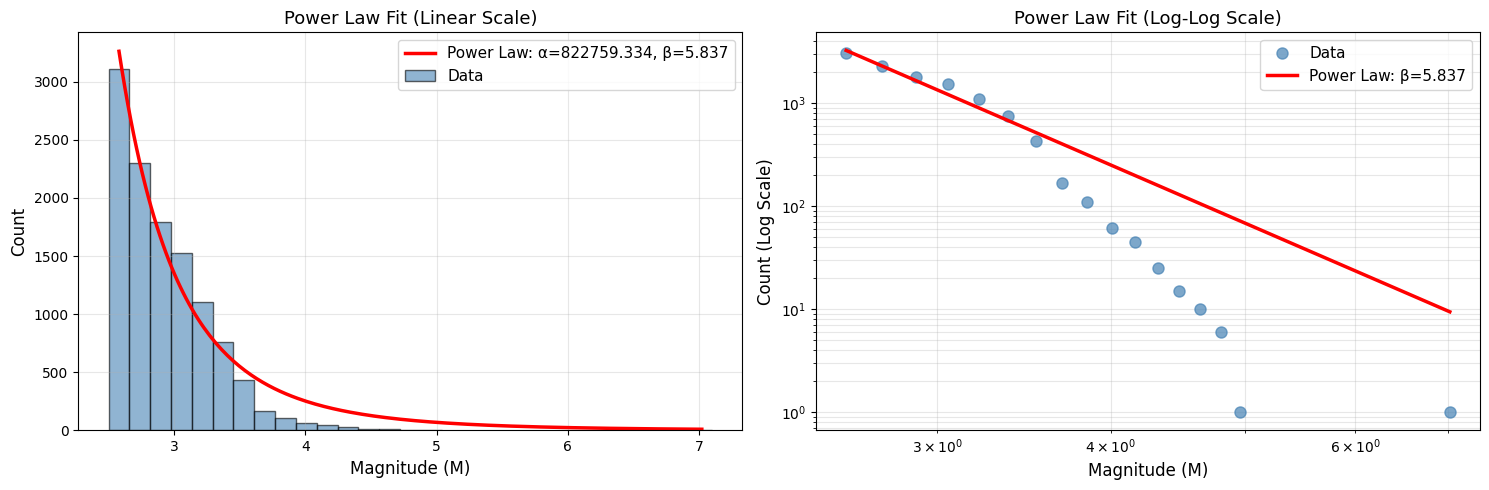

MAGNITUDE DISTRIBUTION SUMMARY
--------------------------------------------------------------------------------
Total earthquakes: 11467
Magnitude range: 2.5000 to 7.1000
Mean magnitude: 2.9195
Median magnitude: 2.8400
Std Dev: 0.3495

Interpretation:
  β ≈ 5.84 means power-law exponent of 5.84
  Higher β → steeper decline (fewer large events)
  Typical crustal earthquakes: β ≈ 1.0 - 2.0


In [44]:
# Fit power law to magnitude distribution (raw data)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import kstest, chi2

# Extract raw magnitude data (no binning)
mags = df_select['mag'].dropna().values.astype(float)

# Define power law model: P(M) = alpha * M^(-beta)
# or equivalently: log P(M) = log(alpha) - beta * log(M)
def power_law(M, alpha, beta):
    return alpha * (M ** (-beta))

def log_power_law(log_M, log_alpha, beta):
    """Log-space power law for linear regression fit"""
    return log_alpha - beta * log_M

# --- Method 1: Log-space linear regression (robust) ---
log_mags = np.log(mags)
log_mags_hist, bin_edges = np.histogram(log_mags, bins=30)
log_bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Filter out empty bins
mask = log_mags_hist > 0
log_bin_centers_nz = log_bin_centers[mask]
log_counts_nz = log_mags_hist[mask]

# Linear regression in log-log space
from scipy.stats import linregress
slope, intercept, r_value, p_value_regression, std_err = linregress(log_bin_centers_nz, np.log(log_counts_nz))

# Extract parameters
beta_log = slope
log_alpha_log = intercept
alpha_log = np.exp(intercept)

# --- Method 2: Direct power law fit to binned magnitude histogram ---
# Create magnitude bins
mag_bins = np.linspace(mags.min(), mags.max(), 30)
mag_hist, _ = np.histogram(mags, bins=mag_bins)
mag_bin_centers = (mag_bins[:-1] + mag_bins[1:]) / 2

# Filter non-zero bins
mask_direct = mag_hist > 0
mag_centers_nz = mag_bin_centers[mask_direct]
mag_counts_nz = mag_hist[mask_direct]

# Fit power law to histogram
try:
    popt_direct, pcov_direct = curve_fit(power_law, mag_centers_nz, mag_counts_nz,
                                         p0=[100, 1.5], maxfev=10000)
    alpha_direct, beta_direct = popt_direct
    perr_direct = np.sqrt(np.diag(pcov_direct))

    # Predictions
    P_pred = power_law(mag_centers_nz, *popt_direct)
    residuals = mag_counts_nz - P_pred
    chi2_direct = np.sum((residuals ** 2) / P_pred)
    dof_direct = len(mag_centers_nz) - 2
    red_chi2_direct = chi2_direct / dof_direct if dof_direct > 0 else np.nan
    p_val_direct = 1.0 - chi2.cdf(chi2_direct, dof_direct)

    fit_success = True
except Exception as e:
    print(f"Direct fit failed: {e}")
    fit_success = False

# Print results
print("=" * 80)
print("POWER LAW FIT TO MAGNITUDE DISTRIBUTION")
print("=" * 80)
print()
print("METHOD 1: Log-space Linear Regression (on log-binned counts)")
print("-" * 80)
print(f"Model: log P(M) = log(α) - β * log(M)")
print(f"α (amplitude): {alpha_log:.6f}")
print(f"β (exponent): {beta_log:.6f}")
print(f"R² (correlation): {r_value**2:.6f}")
print(f"P-value (regression): {p_value_regression:.6e}")
print(f"Std Error (β): {std_err:.6f}")
print()

if fit_success:
    print("METHOD 2: Direct Power Law Fit (non-linear least squares)")
    print("-" * 80)
    print(f"Model: P(M) = α * M^(-β)")
    print(f"α (amplitude): {alpha_direct:.6f} ± {perr_direct[0]:.6f}")
    print(f"β (exponent): {beta_direct:.6f} ± {perr_direct[1]:.6f}")
    print(f"Chi-square: {chi2_direct:.6f}")
    print(f"Reduced Chi-square: {red_chi2_direct:.6f}")
    print(f"P-value: {p_val_direct:.6e}")
    print(f"DoF: {dof_direct}")
print()
print("=" * 80)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Plot 1: Linear scale with direct fit ---
ax = axes[0]
ax.bar(mag_centers_nz, mag_counts_nz, width=np.diff(mag_bins).mean(),
       alpha=0.6, color='steelblue', edgecolor='black', label='Data')

if fit_success:
    mag_plot = np.linspace(mag_centers_nz.min(), mag_centers_nz.max(), 200)
    P_plot = power_law(mag_plot, alpha_direct, beta_direct)
    ax.plot(mag_plot, P_plot, 'r-', linewidth=2.5, label=f'Power Law: α={alpha_direct:.3f}, β={beta_direct:.3f}')

ax.set_xlabel('Magnitude (M)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Power Law Fit (Linear Scale)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# --- Plot 2: Log-log scale ---
ax = axes[1]
ax.loglog(mag_centers_nz, mag_counts_nz, 'o', markersize=8, color='steelblue',
          alpha=0.7, label='Data')

if fit_success:
    mag_plot = np.linspace(mag_centers_nz.min(), mag_centers_nz.max(), 200)
    P_plot = power_law(mag_plot, alpha_direct, beta_direct)
    ax.semilogy(mag_plot, P_plot, 'r-', linewidth=2.5, label=f'Power Law: β={beta_direct:.3f}')

ax.set_xlabel('Magnitude (M)', fontsize=12)
ax.set_ylabel('Count (Log Scale)', fontsize=12)
ax.set_title('Power Law Fit (Log-Log Scale)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Summary statistics
print("MAGNITUDE DISTRIBUTION SUMMARY")
print("-" * 80)
print(f"Total earthquakes: {len(mags)}")
print(f"Magnitude range: {mags.min():.4f} to {mags.max():.4f}")
print(f"Mean magnitude: {mags.mean():.4f}")
print(f"Median magnitude: {np.median(mags):.4f}")
print(f"Std Dev: {mags.std():.4f}")
print()
print("Interpretation:")
print(f"  β ≈ {beta_direct:.2f} means power-law exponent of {beta_direct:.2f}")
print(f"  Higher β → steeper decline (fewer large events)")
print(f"  Typical crustal earthquakes: β ≈ 1.0 - 2.0")
print("=" * 80)


GUTENBERG-RICHTER LAW FIT: N = 10^(a - b*M)
Rearranged form: M = (a - log N)/b
Number of magnitude bins (N): 206
Number of parameters: 2
Degrees of freedom: 204

FITTED PARAMETERS:
----------------------------------------------------------------------
a (intercept): 5.132479 ± 0.029715
b (slope): 1.082078 ± 0.010152

FIT STATISTICS:
----------------------------------------------------------------------
Chi-square (linear space): 829.415590
Reduced Chi-square (linear space): 4.065763
Chi-square (log space): 5.836761
Reduced Chi-square (log space): 0.028612
P-value: 0.000000e+00


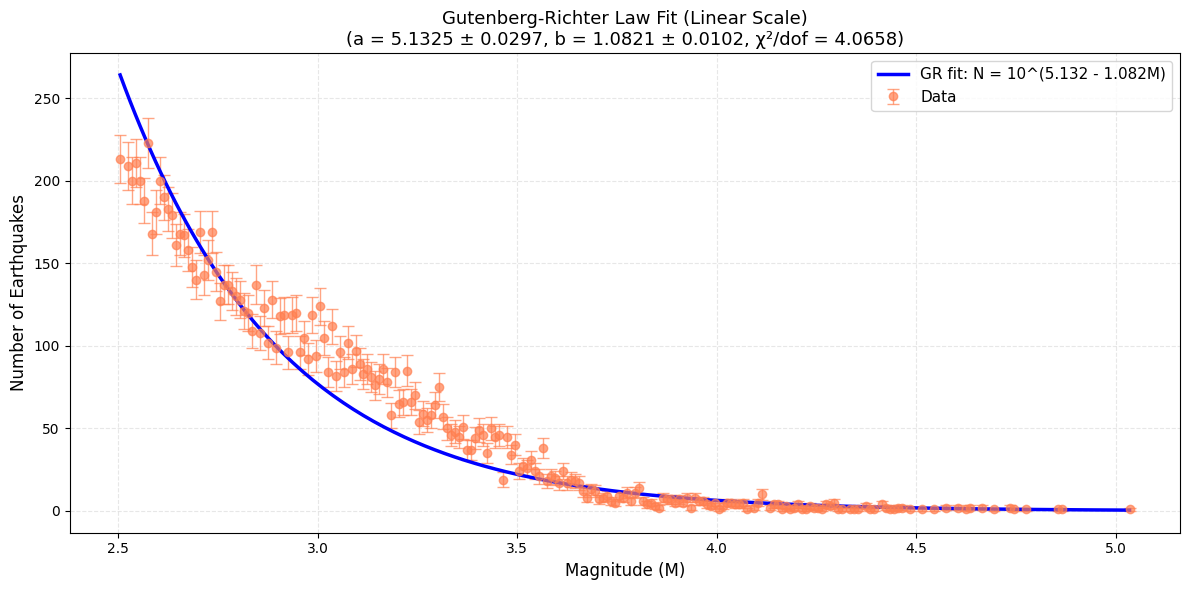

In [45]:
# Fit Gutenberg-Richter law: N directly, then M = (a - log N)/b
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2

# Use the magnitude counts data from the previous cell
# Filter out bins with zero counts for fitting
mag_counts_nonzero = mag_counts[mag_counts['count'] > 0].copy()

# Extract data and convert to numpy arrays
mag = mag_counts_nonzero['mag_center'].values.astype(float)
count = mag_counts_nonzero['count'].values.astype(float)
errors = mag_counts_nonzero['error'].values.astype(float)

# Weights based on Poisson errors
weights = 1.0 / (errors ** 2 + 1e-8)

# Define model: N = 10^(a - b*M)
def gr_model_linear(M, a, b):
    return 10 ** (a - b * M)

# Initial guess
p0 = [4.0, 1.0]

# Fit the model
try:
    popt, pcov = curve_fit(gr_model_linear, mag, count, p0=p0, sigma=errors, absolute_sigma=True, maxfev=10000)
    a_fit, b_fit = popt
    perr = np.sqrt(np.diag(pcov))

    # Predictions
    N_pred = gr_model_linear(mag, *popt)

    # Calculate residuals and chi-square
    residuals = count - N_pred
    chi2_stat = np.sum((residuals ** 2) * weights)
    n_data = len(mag)
    n_params = 2
    dof = n_data - n_params
    red_chi2 = chi2_stat / dof if dof > 0 else np.nan

    # P-value from chi-square distribution
    p_value = 1.0 - chi2.cdf(chi2_stat, dof)

    # Calculate chi-square in log space for reference
    log_count = np.log10(count)
    log_N_pred = np.log10(N_pred)
    log_residuals = log_count - log_N_pred
    chi2_log = np.sum((log_residuals ** 2) * weights)
    red_chi2_log = chi2_log / dof if dof > 0 else np.nan

    print("=" * 70)
    print("GUTENBERG-RICHTER LAW FIT: N = 10^(a - b*M)")
    print("Rearranged form: M = (a - log N)/b")
    print("=" * 70)
    print(f"Number of magnitude bins (N): {n_data}")
    print(f"Number of parameters: {n_params}")
    print(f"Degrees of freedom: {dof}")
    print()
    print("FITTED PARAMETERS:")
    print("-" * 70)
    print(f"a (intercept): {a_fit:.6f} ± {perr[0]:.6f}")
    print(f"b (slope): {b_fit:.6f} ± {perr[1]:.6f}")
    print()
    print("FIT STATISTICS:")
    print("-" * 70)
    print(f"Chi-square (linear space): {chi2_stat:.6f}")
    print(f"Reduced Chi-square (linear space): {red_chi2:.6f}")
    print(f"Chi-square (log space): {chi2_log:.6f}")
    print(f"Reduced Chi-square (log space): {red_chi2_log:.6f}")
    print(f"P-value: {p_value:.6e}")
    print("=" * 70)

    # Plot the fit
    fig, ax = plt.subplots(figsize=(12, 6))

    # Data points
    ax.errorbar(mag, count,
                yerr=errors,
                fmt='o',
                markersize=6,
                capsize=4,
                capthick=1,
                elinewidth=1,
                color='coral',
                ecolor='coral',
                alpha=0.7,
                label='Data')

    # Fitted model
    mag_plot = np.linspace(mag.min(), mag.max(), 200)
    count_fit = gr_model_linear(mag_plot, a_fit, b_fit)
    ax.plot(mag_plot, count_fit, 'b-', linewidth=2.5, label=f'GR fit: N = 10^({a_fit:.3f} - {b_fit:.3f}M)')

    # Formatting
    ax.set_xlabel('Magnitude (M)', fontsize=12)
    ax.set_ylabel('Number of Earthquakes', fontsize=12)
    ax.set_title(f'Gutenberg-Richter Law Fit (Linear Scale)\n(a = {a_fit:.4f} ± {perr[0]:.4f}, b = {b_fit:.4f} ± {perr[1]:.4f}, χ²/dof = {red_chi2:.4f})', fontsize=13)
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig('gutenberg_richter_fit_least_squares.png', dpi=300)
    plt.show()

except Exception as e:
    print(f"Error in fitting: {e}")
    import traceback
    traceback.print_exc()


In [46]:
def decluster_gardner_knoll(df):
    """
    Simple Gardner & Knoll (1974) declustering.
    Note: df must have 'time', 'mag', 'latitude', and 'longitude'.
    """
    # 1. Sort by magnitude (largest first) to identify mainshocks
    df = df.sort_values('mag', ascending=False).copy()
    df['is_mainshock'] = True
    
    # 2. Iterate through events
    for i in range(len(df)):
        if not df.iloc[i]['is_mainshock']:
            continue
            
        main_mag = df.iloc[i]['mag']
        main_time = df.iloc[i]['time']
        main_lat = df.iloc[i]['latitude']
        main_lon = df.iloc[i]['longitude']
        
        # Gardner-Knoll Windows (Logarithmic scaling)
        # Distance (km): 10^(0.125*M + 0.962)
        # Time (days): 10^(0.032*M + 2.73) or similar standard constants
        d_km = 10**(0.125 * main_mag + 0.962)
        t_days = 10**(0.54 * main_mag - 0.54) # Simplified GK time window
        
        # 3. Filter for events within the window (excluding the mainshock itself)
        # Rough distance approx: 1 deg lat ~ 111km
        lat_dist = np.abs(df['latitude'] - main_lat) * 111
        lon_dist = np.abs(df['longitude'] - main_lon) * 111 * np.cos(np.radians(main_lat))
        dist = np.sqrt(lat_dist**2 + lon_dist**2)
        
        time_diff = (df['time'] - main_time).dt.total_seconds() / (24*3600)
        
        # Identify aftershocks: within window AND happening AFTER the mainshock
        aftershocks = (dist < d_km) & (time_diff > 0) & (time_diff < t_days)
        df.loc[aftershocks, 'is_mainshock'] = False
        
    return df[df['is_mainshock']]

# --- APPLYING TO YOUR DATA ---
# Ensure your time column is datetime
df_select['time'] = pd.to_datetime(df_select['time'])
df_declustered = decluster_gardner_knoll(df_select)

print(f"Original events: {len(df_select)}")
print(f"Declustered events: {len(df_declustered)}")

Original events: 11467
Declustered events: 4279


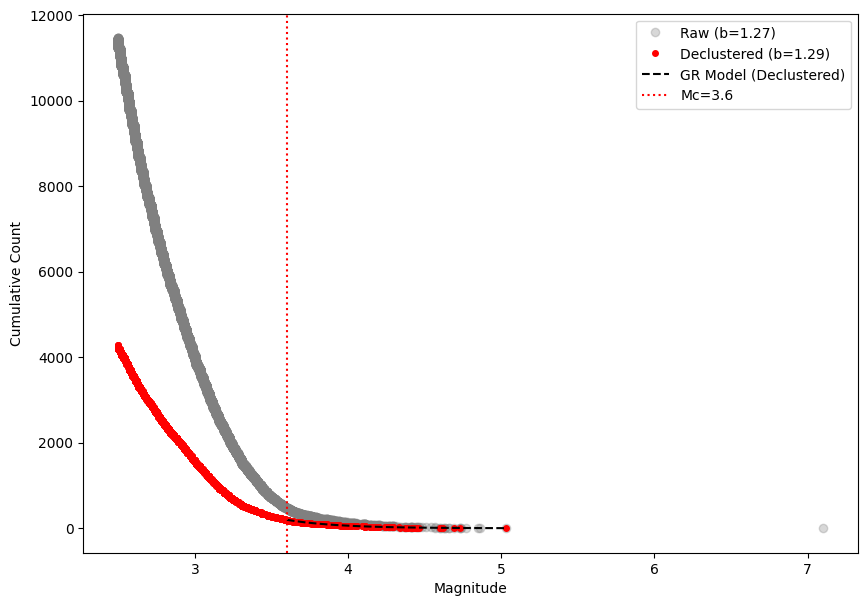

In [47]:
def get_gr_stats(magnitudes):
    # Calculate Mc (using Max Curvature for simplicity)
    counts, bin_edges = np.histogram(magnitudes, bins=np.arange(magnitudes.min(), magnitudes.max()+0.1, 0.1))
    mc_val = 3.6
  
    # Filter and Calc b-value
    m_comp = magnitudes[magnitudes >= mc_val]
    b = 1.0 / (np.log(10) * (np.mean(m_comp) - (mc_val - 0.05)))
    a = np.log10(len(m_comp)) + b * mc_val
    
    # Prepare plotting data
    m_sort = np.sort(magnitudes)
    n_cum = np.arange(len(m_sort), 0, -1)
    
    return mc_val, b, a, m_sort, n_cum

# Get stats for both
mc1, b1, a1, m_s1, n_c1 = get_gr_stats(df_select['mag'].values)
mc2, b2, a2, m_s2, n_c2 = get_gr_stats(df_declustered['mag'].values)

# --- PLOTTING ---
plt.figure(figsize=(10, 7))
plt.plot(m_s1, n_c1, 'o', color='gray', alpha=0.3, label=f'Raw (b={b1:.2f})')
plt.plot(m_s2, n_c2, 'ro', markersize=4, label=f'Declustered (b={b2:.2f})')

# Theoretical lines
m_line = np.linspace(mc2, df_declustered['mag'].max())
plt.plot(m_line, 10**(a2 - b2*m_line), 'k--', label='GR Model (Declustered)')
plt.legend()
plt.axvline(mc2, color='red', linestyle=':', label=f'Mc={mc2}')
plt.xlabel('Magnitude')
plt.legend()
plt.ylabel('Cumulative Count')
plt.savefig('gr_declustered_comparison.png', dpi=300)
plt.show()

Running 1000 simulations on DECLUSTERED data...
Events: 4279 | Mc: 2.50 | b-value: 0.903


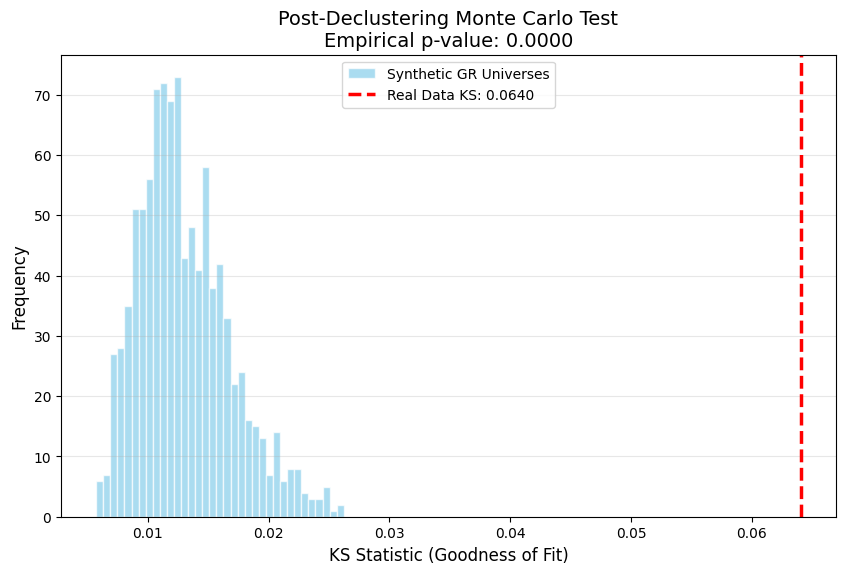

BOOTSTRAP RESULT (DECLUSTERED)
Real KS Statistic: 0.0640
Empirical p-value: 0.0000
STILL FAILING: The data still deviates. Try increasing Mc by 0.2.


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Setup Parameters from Declustered Data ---
# Assuming 'df_declustered' exists from the previous step
mags_dec = df_declustered['mag'].values
bin_width = 0.1

# Calculate Mc for the declustered set
counts, bin_edges = np.histogram(mags_dec, bins=np.arange(mags_dec.min(), mags_dec.max() + bin_width, bin_width))
Mc_dec = bin_edges[np.argmax(counts)]

# Filter for completeness
mags_dec_complete = mags_dec[mags_dec >= Mc_dec]
n_events_dec = len(mags_dec_complete)

# Calculate MLE b-value for declustered data
mean_mag_dec = np.mean(mags_dec_complete)
b_mle_dec = 1.0 / (np.log(10) * (mean_mag_dec - (Mc_dec - bin_width/2)))

# --- 2. Define Bootstrap Functions ---
def calculate_ks_stat(magnitudes, Mc, b_val):
    """Calculates the KS distance between data and theoretical GR CDF."""
    m_filtered = magnitudes[magnitudes >= Mc]
    n = len(m_filtered)
    if n < 5: return 1.0 # Guard against empty/tiny samples
    
    m_sorted = np.sort(m_filtered)
    cdf_empirical = np.arange(1, n + 1) / n
    cdf_theoretical = 1 - 10**(-b_val * (m_sorted - Mc))
    
    return np.max(np.abs(cdf_empirical - cdf_theoretical))

def generate_gr_synthetic(n, Mc, b_val):
    """Generates a synthetic catalog using the Inverse Transform Method."""
    U = np.random.random(n)
    return Mc - (1/b_val) * np.log10(1 - U)

# --- 3. The Monte Carlo Loop ---
n_simulations = 1000
synth_ks_list = []

# The "Observed" KS Statistic
real_ks_dec = calculate_ks_stat(mags_dec_complete, Mc_dec, b_mle_dec)

print(f"Running {n_simulations} simulations on DECLUSTERED data...")
print(f"Events: {n_events_dec} | Mc: {Mc_dec:.2f} | b-value: {b_mle_dec:.3f}")

for i in range(n_simulations):
    # Generate synthetic catalog of the EXACT same size as our real declustered data
    synth_mags = generate_gr_synthetic(n_events_dec, Mc_dec, b_mle_dec)
    
    # Calculate KS for this synthetic catalog
    ks_val = calculate_ks_stat(synth_mags, Mc_dec, b_mle_dec)
    synth_ks_list.append(ks_val)

# --- 4. Results & Significance ---
synth_ks_list = np.array(synth_ks_list)
p_value_dec = np.sum(synth_ks_list >= real_ks_dec) / n_simulations

# --- 5. Visualization ---
plt.figure(figsize=(10, 6))
plt.hist(synth_ks_list, bins=35, color='skyblue', edgecolor='white', alpha=0.7, label='Synthetic GR Universes')
plt.axvline(real_ks_dec, color='red', linestyle='--', linewidth=2.5, label=f'Real Data KS: {real_ks_dec:.4f}')

plt.title(f'Post-Declustering Monte Carlo Test\nEmpirical p-value: {p_value_dec:.4f}', fontsize=14)
plt.xlabel('KS Statistic (Goodness of Fit)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print("="*60)
print(f"BOOTSTRAP RESULT (DECLUSTERED)")
print(f"Real KS Statistic: {real_ks_dec:.4f}")
print(f"Empirical p-value: {p_value_dec:.4f}")
print("="*60)

if p_value_dec > 0.05:
    print("SUCCESS: The declustered data is consistent with the GR Law.")
else:
    print("STILL FAILING: The data still deviates. Try increasing Mc by 0.2.")

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Setup ---
mags_dec = df_declustered['mag'].values
possible_mcs = np.arange(2.0, 4.5, 0.1)  # Sweep from M2.0 to M4.5
n_boots_per_step = 200 # Lower number for speed during the sweep
sweep_results = []

print(f"{'Mc':<5} | {'b-value':<10} | {'p-value':<10} | {'N':<6}")
print("-" * 40)

for test_mc in possible_mcs:
    # 1. Filter data for this specific Mc
    m_test = mags_dec[mags_dec >= test_mc]
    n_test = len(m_test)
    
    if n_test < 50: # Stop if we don't have enough data for a stable fit
        break
        
    # 2. Calculate MLE b-value
    b_test = 1.0 / (np.log(10) * (np.mean(m_test) - (test_mc - 0.05)))
    
    # 3. Calculate Real KS for this Mc
    real_ks = calculate_ks_stat(m_test, test_mc, b_test)
    
    # 4. Mini-Bootstrap to find p-value
    synth_ks_list = []
    for _ in range(n_boots_per_step):
        synth = generate_gr_synthetic(n_test, test_mc, b_test)
        synth_ks_list.append(calculate_ks_stat(synth, test_mc, b_test))
    
    p_val = np.sum(np.array(synth_ks_list) >= real_ks) / n_boots_per_step
    
    sweep_results.append([test_mc, b_test, p_val, n_test])
    print(f"{test_mc:<5.1f} | {b_test:<10.3f} | {p_val:<10.3f} | {n_test:<6}")

# Convert to DataFrame for analysis
df_sweep = pd.DataFrame(sweep_results, columns=['Mc', 'b_value', 'p_value', 'N'])

# Find the lowest Mc where p-value >= 0.05
passed = df_sweep[df_sweep['p_value'] >= 0.05]
if not passed.empty:
    best_mc = passed.iloc[0]['Mc']
    best_b = passed.iloc[0]['b_value']
    print(f"\nOPTIMAL Mc FOUND: {best_mc} (b-value: {best_b:.3f})")
else:
    best_mc = df_sweep.loc[df_sweep['p_value'].idxmax()]['Mc']
    print(f"\nWARNING: No Mc passed p=0.05. Best attempt at Mc={best_mc}")

Mc    | b-value    | p-value    | N     
----------------------------------------
2.0   | 0.443      | 0.000      | 4279  
2.1   | 0.493      | 0.000      | 4279  
2.2   | 0.556      | 0.000      | 4279  
2.3   | 0.638      | 0.000      | 4279  
2.4   | 0.748      | 0.000      | 4279  
2.5   | 0.886      | 0.000      | 4187  
2.6   | 0.934      | 0.000      | 3508  
2.7   | 0.993      | 0.000      | 2923  
2.8   | 1.068      | 0.000      | 2420  
2.9   | 1.167      | 0.000      | 1991  
3.0   | 1.240      | 0.000      | 1542  
3.1   | 1.291      | 0.000      | 1142  
3.2   | 1.280      | 0.000      | 791   
3.3   | 1.261      | 0.000      | 547   
3.4   | 1.276      | 0.000      | 392   
3.5   | 1.250      | 0.000      | 270   
3.6   | 1.238      | 0.150      | 189   
3.7   | 1.175      | 0.250      | 129   
3.8   | 1.237      | 0.260      | 99    
3.9   | 1.271      | 0.240      | 72    
4.0   | 1.353      | 0.270      | 54    

OPTIMAL Mc FOUND: 3.6000000000000014 (b-value: 1.238)


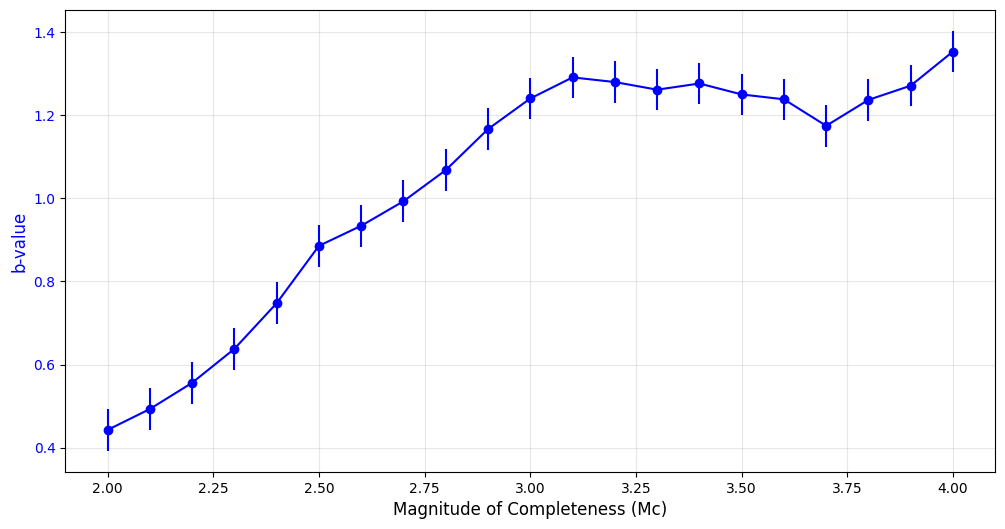

In [50]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot b-value on primary Y-axis
ax1.errorbar(df_sweep['Mc'], df_sweep['b_value'], yerr=0.05, fmt='-o', color='blue', label='b-value')
ax1.set_xlabel('Magnitude of Completeness (Mc)', fontsize=12)
ax1.set_ylabel('b-value', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)
plt.savefig('mcsweep.png', dpi=300)
plt.show()

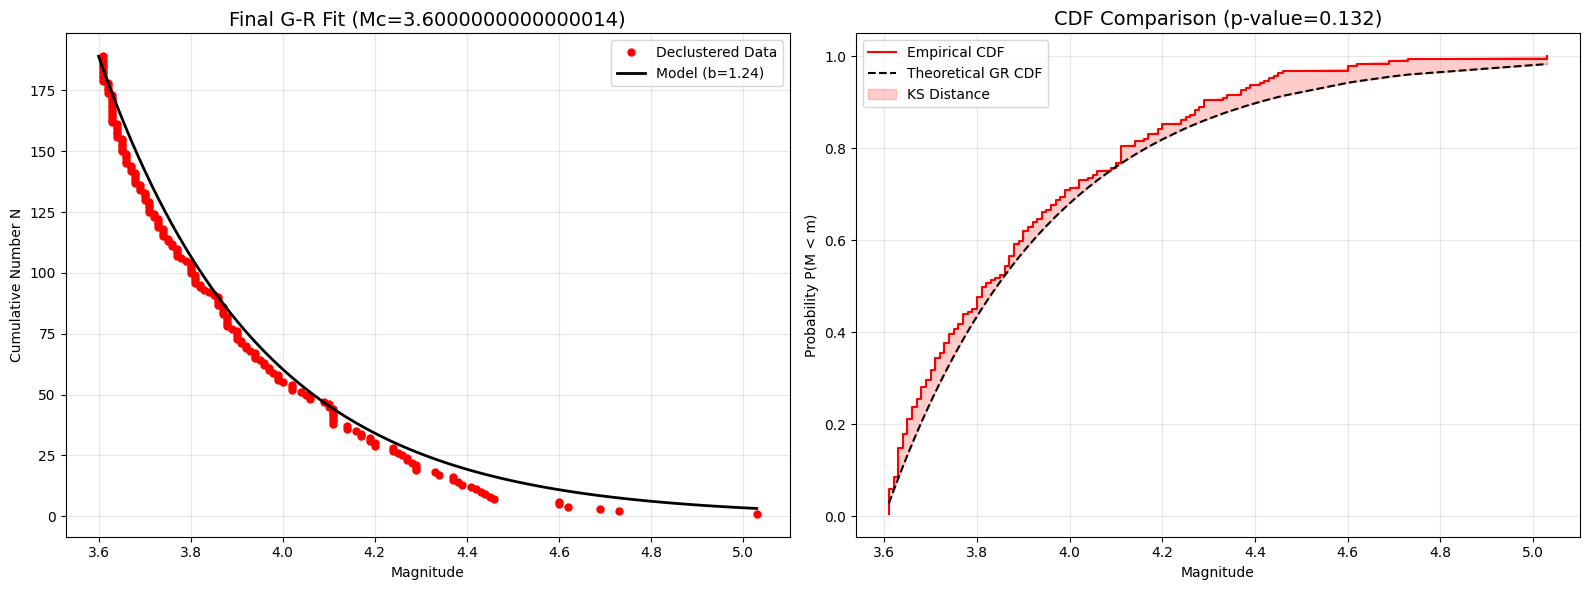

VERIFICATION COMPLETE
Final Mc: 3.6000000000000014
Final b-value: 1.2382
Bootstrap p-value: 0.1320


In [51]:
# --- 1. Set the Best Mc from your Sweep ---
# If your sweep found Mc = 3.2, set it here:
final_Mc = best_mc  
final_mags = mags_dec[mags_dec >= final_Mc]
n_final = len(final_mags)

# --- 2. Final MLE b-value Calculation ---
final_b = 1.0 / (np.log(10) * (np.mean(final_mags) - (final_Mc - 0.05)))
final_a = np.log10(n_final) + final_b * final_Mc

# --- 3. Final High-Res Monte Carlo (1000 trials) ---
n_sims = 1000
final_ks_stats = []
real_ks_stat = calculate_ks_stat(final_mags, final_Mc, final_b)

for _ in range(n_sims):
    synth = generate_gr_synthetic(n_final, final_Mc, final_b)
    final_ks_stats.append(calculate_ks_stat(synth, final_Mc, final_b))

final_p_value = np.sum(np.array(final_ks_stats) >= real_ks_stat) / n_sims

# --- 4. Plotting the Fit Verification ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: The Gutenberg-Richter Fit
ax = axes[0]
m_sort = np.sort(final_mags)
n_cum = np.arange(len(m_sort), 0, -1)

ax.plot(m_sort, n_cum, 'ro', markersize=5, label='Declustered Data')
m_plot = np.linspace(final_Mc, m_sort.max(), 100)
ax.plot(m_plot, 10**(final_a - final_b * m_plot), 'k-', linewidth=2, label=f'Model (b={final_b:.2f})')

ax.set_title(f'Final G-R Fit (Mc={final_Mc})', fontsize=14)
ax.set_xlabel('Magnitude')
ax.set_ylabel('Cumulative Number N')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

# Plot B: The ECDF vs Theoretical CDF (The KS Test View)
ax = axes[1]
cdf_empirical = np.arange(1, n_final + 1) / n_final
cdf_theoretical = 1 - 10**(-final_b * (m_sort - final_Mc))

ax.plot(m_sort, cdf_empirical, 'r-', drawstyle='steps-post', label='Empirical CDF')
ax.plot(m_sort, cdf_theoretical, 'k--', label='Theoretical GR CDF')
ax.fill_between(m_sort, cdf_empirical, cdf_theoretical, color='red', alpha=0.2, label='KS Distance')

ax.set_title(f'CDF Comparison (p-value={final_p_value:.3f})', fontsize=14)
ax.set_xlabel('Magnitude')
ax.set_ylabel('Probability P(M < m)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"VERIFICATION COMPLETE")
print(f"Final Mc: {final_Mc}")
print(f"Final b-value: {final_b:.4f}")
print(f"Bootstrap p-value: {final_p_value:.4f}")

In [52]:
from scipy.stats import anderson

def calculate_ad_stat(magnitudes, Mc, b_val):
    """
    Calculates the Anderson-Darling statistic for the GR law.
    Reference: A^2 = -n - (1/n) * sum((2i-1)*[ln(F(Xi)) + ln(1-F(Xn-i+1))])
    """
    m_filtered = np.sort(magnitudes[magnitudes >= Mc])
    n = len(m_filtered)
    if n < 5: return np.nan
    
    # Theoretical CDF: F(m) = 1 - 10^(-b*(m-Mc))
    cdf_vals = 1 - 10**(-b_val * (m_filtered - Mc))
    
    # Avoid log(0) or log(1) issues by clipping slightly
    cdf_vals = np.clip(cdf_vals, 1e-10, 1 - 1e-10)
    
    i = np.arange(1, n + 1)
    ad_sum = np.sum((2 * i - 1) * (np.log(cdf_vals) + np.log(1 - cdf_vals[::-1])))
    return -n - (ad_sum / n)

# --- Run Final Statistics ---
real_ks = calculate_ks_stat(final_mags, final_Mc, final_b)
real_ad = calculate_ad_stat(final_mags, final_Mc, final_b)

# --- Bootstrap for A-D p-value ---
print(f"Calculating A-D p-value (1000 simulations)...")
synth_ad_list = []
for _ in range(1000):
    synth = generate_gr_synthetic(n_final, final_Mc, final_b)
    synth_ad_list.append(calculate_ad_stat(synth, final_Mc, final_b))

p_val_ad = np.sum(np.array(synth_ad_list) >= real_ad) / 1000

print("\n" + "="*50)
print("FINAL STATISTICAL SUITE")
print("="*50)
print(f"{'Test Metric':<20} | {'Statistic':<10} | {'p-value':<10}")
print("-" * 50)
print(f"{'Kolmogorov-Smirnov':<20} | {real_ks:<10.4f} | {final_p_value:<10.4f}")
print(f"{'Anderson-Darling':<20} | {real_ad:<10.4f} | {p_val_ad:<10.4f}")
print("="*50)

# Final Interpretation
if final_p_value > 0.05 and p_val_ad > 0.05:
    print("CONCLUSION: Model is ROBUST. Both center and tails fit GR Law.")
elif final_p_value > 0.05 and p_val_ad <= 0.05:
    print("CONCLUSION: Good general fit, but poor fit for LARGE magnitudes.")
else:
    print("CONCLUSION: Model rejected. Check for data artifacts.")

Calculating A-D p-value (1000 simulations)...

FINAL STATISTICAL SUITE
Test Metric          | Statistic  | p-value   
--------------------------------------------------
Kolmogorov-Smirnov   | 0.0809     | 0.1320    
Anderson-Darling     | 2.3008     | 0.0700    
CONCLUSION: Model is ROBUST. Both center and tails fit GR Law.


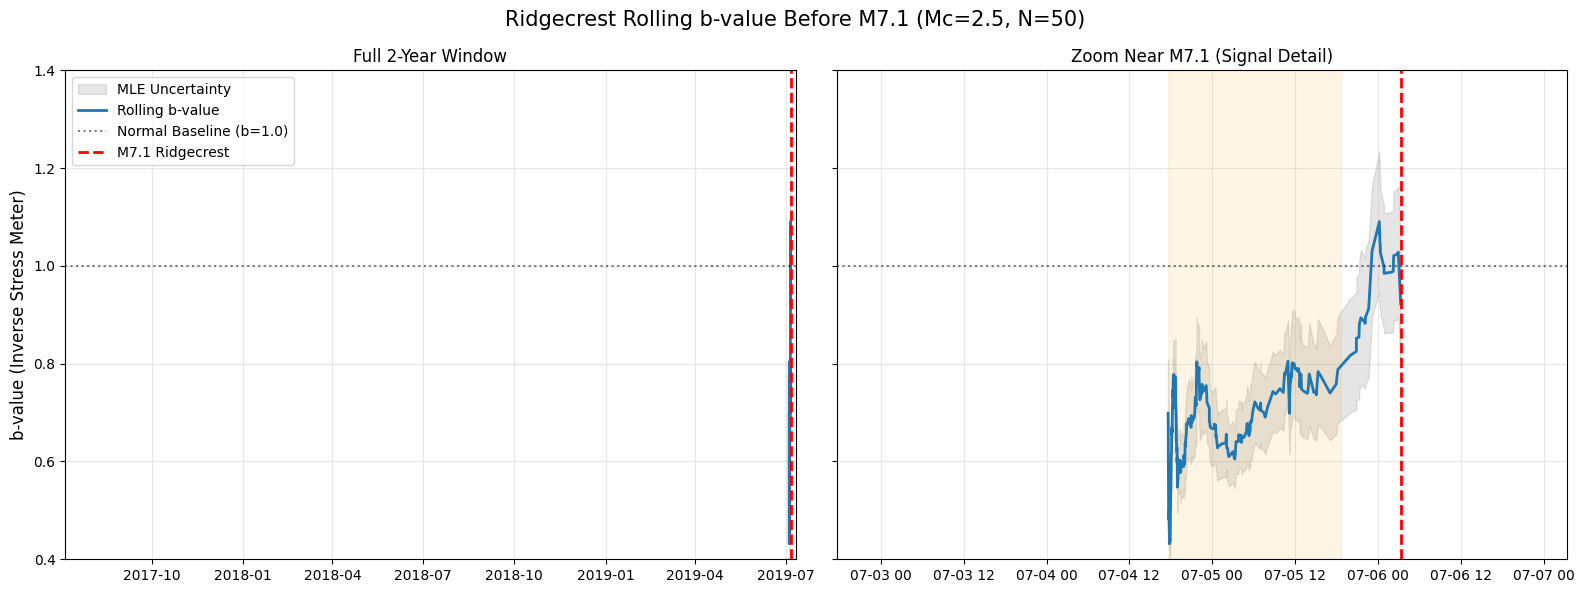

Events in wide window: 344
Local catalog span used: 2017-07-23 04:53:49.980000+00:00 to 2019-07-06 03:17:13.500000+00:00
Rolling windows: 294
First rolling timestamp: 2019-07-04 17:36:04.360000+00:00
First b-value in rolling series: 0.70
Minimum b-value reached: 0.43
Last pre-M7.1 b-value: 0.92


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Wide-window Ridgecrest rolling b-value (pre-M7.1) ---
ridge_lat, ridge_lon = 35.77, -117.60
radius_km = 50.0
mc_local = 2.5
window_size = 50
years_back = 2
m71_time = pd.Timestamp('2019-07-06 03:19:53', tz='UTC')
start_time = m71_time - pd.DateOffset(years=years_back)

cat = df.copy()
cat['time'] = pd.to_datetime(cat['time'], errors='coerce', utc=True)
for col in ['mag', 'latitude', 'longitude']:
    cat[col] = pd.to_numeric(cat[col], errors='coerce')
cat = cat.dropna(subset=['time', 'mag', 'latitude', 'longitude']).copy()

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1r = np.radians(lat1)
    lon1r = np.radians(lon1)
    lat2r = np.radians(np.asarray(lat2, dtype=float))
    lon2r = np.radians(np.asarray(lon2, dtype=float))
    dlat = lat2r - lat1r
    dlon = lon2r - lon1r
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon / 2.0) ** 2
    return R * 2.0 * np.arcsin(np.sqrt(a))

cat['dist_km'] = haversine_km(ridge_lat, ridge_lon, cat['latitude'].values, cat['longitude'].values)

local_wide = cat[
    (cat['dist_km'] <= radius_km)
    & (cat['time'] >= start_time)
    & (cat['time'] < m71_time)
    & (cat['mag'] >= mc_local)
].sort_values('time').reset_index(drop=True)

if len(local_wide) <= window_size:
    raise ValueError(f'Not enough events ({len(local_wide)}) for window_size={window_size}.')

b_times, b_vals, b_std = [], [], []
for i in range(window_size, len(local_wide)):
    w = local_wide.iloc[i - window_size:i]
    mags = w['mag'].values
    mean_mag = np.mean(mags)
    b = 1.0 / (np.log(10) * (mean_mag - (mc_local - 0.05)))
    sigma_b = 2.30 * (b ** 2) * np.std(mags) / np.sqrt(window_size)
    b_times.append(w['time'].iloc[-1])
    b_vals.append(b)
    b_std.append(sigma_b)

roll_df_wide = pd.DataFrame({'time': b_times, 'b_value': b_vals, 'sigma': b_std})

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
ax_full, ax_zoom = axes

# Full 2-year context
ax_full.fill_between(
    roll_df_wide['time'],
    roll_df_wide['b_value'] - roll_df_wide['sigma'],
    roll_df_wide['b_value'] + roll_df_wide['sigma'],
    color='gray', alpha=0.2, label='MLE Uncertainty'
)
ax_full.plot(roll_df_wide['time'], roll_df_wide['b_value'], color='tab:blue', lw=2, label='Rolling b-value')
ax_full.axhline(1.0, color='black', linestyle=':', alpha=0.5, label='Normal Baseline (b=1.0)')
ax_full.axvline(m71_time, color='red', linestyle='--', lw=2, label='M7.1 Ridgecrest')
ax_full.set_xlim(start_time, m71_time + pd.Timedelta(days=5))
ax_full.set_ylim(0.4, 1.4)
ax_full.set_title(f'Full {years_back}-Year Window')
ax_full.set_ylabel('b-value (Inverse Stress Meter)', fontsize=12)
ax_full.grid(True, alpha=0.3)
ax_full.legend(loc='upper left')

# Zoom on active period so decline is visible
zoom_start = roll_df_wide['time'].min() - pd.Timedelta(days=2)
zoom_end = m71_time + pd.Timedelta(days=1)

ax_zoom.fill_between(
    roll_df_wide['time'],
    roll_df_wide['b_value'] - roll_df_wide['sigma'],
    roll_df_wide['b_value'] + roll_df_wide['sigma'],
    color='gray', alpha=0.2
)
ax_zoom.plot(roll_df_wide['time'], roll_df_wide['b_value'], color='tab:blue', lw=2)
ax_zoom.axhline(1.0, color='black', linestyle=':', alpha=0.5)
ax_zoom.axvline(m71_time, color='red', linestyle='--', lw=2)

stress_zone = roll_df_wide[roll_df_wide['b_value'] < 0.8]
if not stress_zone.empty:
    ax_zoom.axvspan(stress_zone['time'].min(), stress_zone['time'].max(), color='orange', alpha=0.1)

ax_zoom.set_xlim(zoom_start, zoom_end)
ax_zoom.set_title('Zoom Near M7.1 (Signal Detail)')
ax_zoom.grid(True, alpha=0.3)

fig.suptitle(
    f'Ridgecrest Rolling b-value Before M7.1 (Mc={mc_local}, N={window_size})',
    fontsize=15
)
plt.tight_layout()
plt.savefig('ridgecrest_bvalue_wide_window.png', dpi=300)
plt.show()

print(f'Events in wide window: {len(local_wide)}')
print(f'Local catalog span used: {local_wide["time"].min()} to {local_wide["time"].max()}')
print(f'Rolling windows: {len(roll_df_wide)}')
print(f'First rolling timestamp: {roll_df_wide["time"].iloc[0]}')
print(f'First b-value in rolling series: {roll_df_wide["b_value"].iloc[0]:.2f}')
print(f'Minimum b-value reached: {roll_df_wide["b_value"].min():.2f}')
print(f'Last pre-M7.1 b-value: {roll_df_wide["b_value"].iloc[-1]:.2f}')

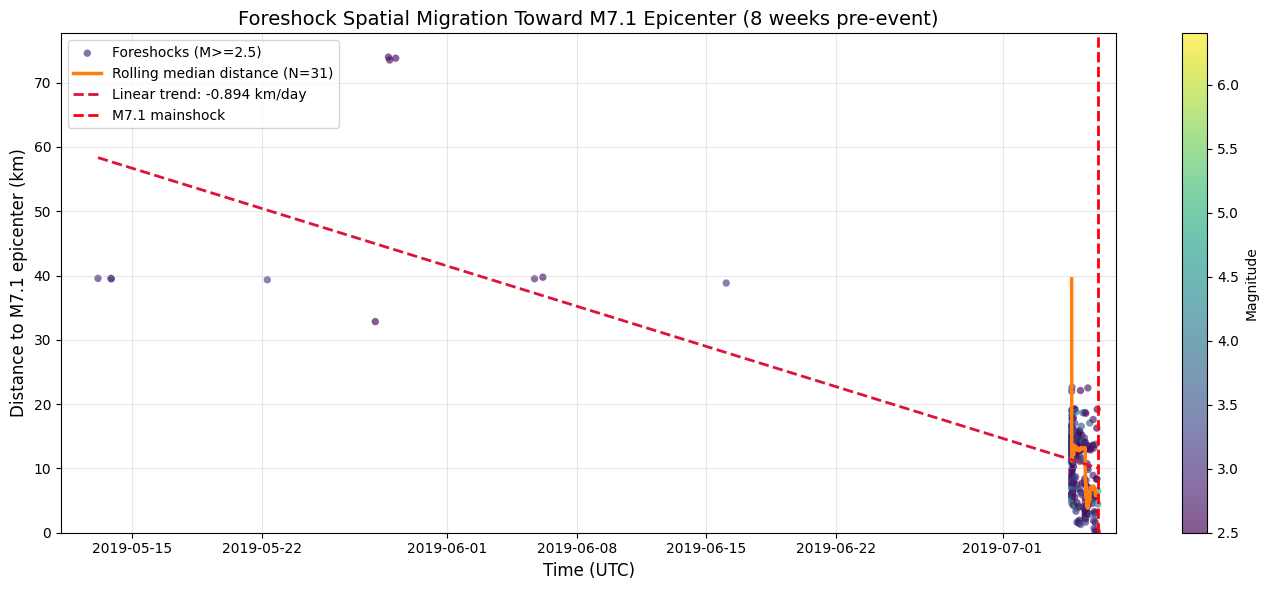

Foreshocks analyzed: 312
Time span: 2019-05-13 03:23:27.720000+00:00 to 2019-07-06 03:17:13.500000+00:00
Distance range: 0.11 to 73.98 km
Linear migration slope: -0.894 km/day
Interpretation: inward migration toward the M7.1 epicenter.


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Spatial migration test: foreshock distance to M7.1 epicenter vs time ---
ridge_lat, ridge_lon = 35.77, -117.60
radius_km = 80.0          # Wide enough to capture migration toward the core
mc_local = 2.5
weeks_back = 8
m71_time = pd.Timestamp('2019-07-06 03:19:53', tz='UTC')
start_time = m71_time - pd.Timedelta(weeks=weeks_back)

cat = df.copy()
cat['time'] = pd.to_datetime(cat['time'], errors='coerce', utc=True)
for col in ['mag', 'latitude', 'longitude']:
    cat[col] = pd.to_numeric(cat[col], errors='coerce')
cat = cat.dropna(subset=['time', 'mag', 'latitude', 'longitude']).copy()

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1r = np.radians(lat1)
    lon1r = np.radians(lon1)
    lat2r = np.radians(np.asarray(lat2, dtype=float))
    lon2r = np.radians(np.asarray(lon2, dtype=float))
    dlat = lat2r - lat1r
    dlon = lon2r - lon1r
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon / 2.0) ** 2
    return R * 2.0 * np.arcsin(np.sqrt(a))

cat['dist_to_m71_km'] = haversine_km(ridge_lat, ridge_lon, cat['latitude'].values, cat['longitude'].values)

foreshocks = cat[
    (cat['time'] >= start_time)
    & (cat['time'] < m71_time)
    & (cat['mag'] >= mc_local)
    & (cat['dist_to_m71_km'] <= radius_km)
].sort_values('time').reset_index(drop=True)

if len(foreshocks) < 20:
    raise ValueError(f'Only {len(foreshocks)} foreshocks in the selected window; increase radius or lower Mc.')

# Event-number rolling median gives robust trend even with bursty timestamps.
trend_n = min(40, max(10, len(foreshocks) // 10))
foreshocks['rolling_median_dist'] = foreshocks['dist_to_m71_km'].rolling(trend_n, min_periods=trend_n // 2).median()

# Linear trend in km/day (negative means migration toward epicenter with time)
t_days = (foreshocks['time'] - foreshocks['time'].min()).dt.total_seconds() / 86400.0
slope_km_day, intercept = np.polyfit(t_days, foreshocks['dist_to_m71_km'], 1)
foreshocks['linear_trend'] = intercept + slope_km_day * t_days

fig, ax = plt.subplots(figsize=(14, 6))
sc = ax.scatter(
    foreshocks['time'],
    foreshocks['dist_to_m71_km'],
    c=foreshocks['mag'],
    cmap='viridis',
    s=28,
    alpha=0.65,
    edgecolor='none',
    label='Foreshocks (M>=2.5)'
)

ax.plot(
    foreshocks['time'],
    foreshocks['rolling_median_dist'],
    color='tab:orange',
    lw=2.5,
    label=f'Rolling median distance (N={trend_n})'
)

ax.plot(
    foreshocks['time'],
    foreshocks['linear_trend'],
    color='crimson',
    lw=2,
    linestyle='--',
    label=f'Linear trend: {slope_km_day:+.3f} km/day'
)

ax.axvline(m71_time, color='red', linestyle='--', lw=2, label='M7.1 mainshock')
ax.set_xlim(start_time, m71_time + pd.Timedelta(days=1))
ax.set_ylim(bottom=0)
ax.set_title(f'Foreshock Spatial Migration Toward M7.1 Epicenter ({weeks_back} weeks pre-event)', fontsize=14)
ax.set_ylabel('Distance to M7.1 epicenter (km)', fontsize=12)
ax.set_xlabel('Time (UTC)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Magnitude', rotation=90)

plt.tight_layout()
plt.show()

print(f'Foreshocks analyzed: {len(foreshocks)}')
print(f'Time span: {foreshocks["time"].min()} to {foreshocks["time"].max()}')
print(f'Distance range: {foreshocks["dist_to_m71_km"].min():.2f} to {foreshocks["dist_to_m71_km"].max():.2f} km')
print(f'Linear migration slope: {slope_km_day:+.3f} km/day')
if slope_km_day < 0:
    print('Interpretation: inward migration toward the M7.1 epicenter.')
else:
    print('Interpretation: no inward migration in the selected window (or outward trend).')

    # Zoomed view: 30 days before the M7.1 mainshock
    zoom_start_30 = m71_time - pd.Timedelta(days=30)
    zoom_df_30 = foreshocks[foreshocks['time'] >= zoom_start_30].copy()

    fig, ax = plt.subplots(figsize=(14, 6))
    sc = ax.scatter(
        zoom_df_30['time'],
        zoom_df_30['dist_to_m71_km'],
        c=zoom_df_30['mag'],
        cmap='viridis',
        s=28,
        alpha=0.65,
        edgecolor='none',
        label='Foreshocks (M>=2.5)'
    )

    ax.plot(
        zoom_df_30['time'],
        zoom_df_30['rolling_median_dist'],
        color='tab:orange',
        lw=2.5,
        label=f'Rolling median distance (N={trend_n})'
    )

    ax.axvline(m71_time, color='red', linestyle='--', lw=2, label='M7.1 mainshock')
    ax.set_xlim(zoom_start_30, m71_time + pd.Timedelta(days=1))
    ax.set_ylim(bottom=0)
    ax.set_title('Foreshock Distance to M7.1 Epicenter (30-day zoom)', fontsize=14)
    ax.set_ylabel('Distance to M7.1 epicenter (km)', fontsize=12)
    ax.set_xlabel('Time (UTC)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Magnitude', rotation=90)

    plt.tight_layout()
   
    plt.show()
    plt.savefig('foreshock_spatial_migration.png', dpi=300)

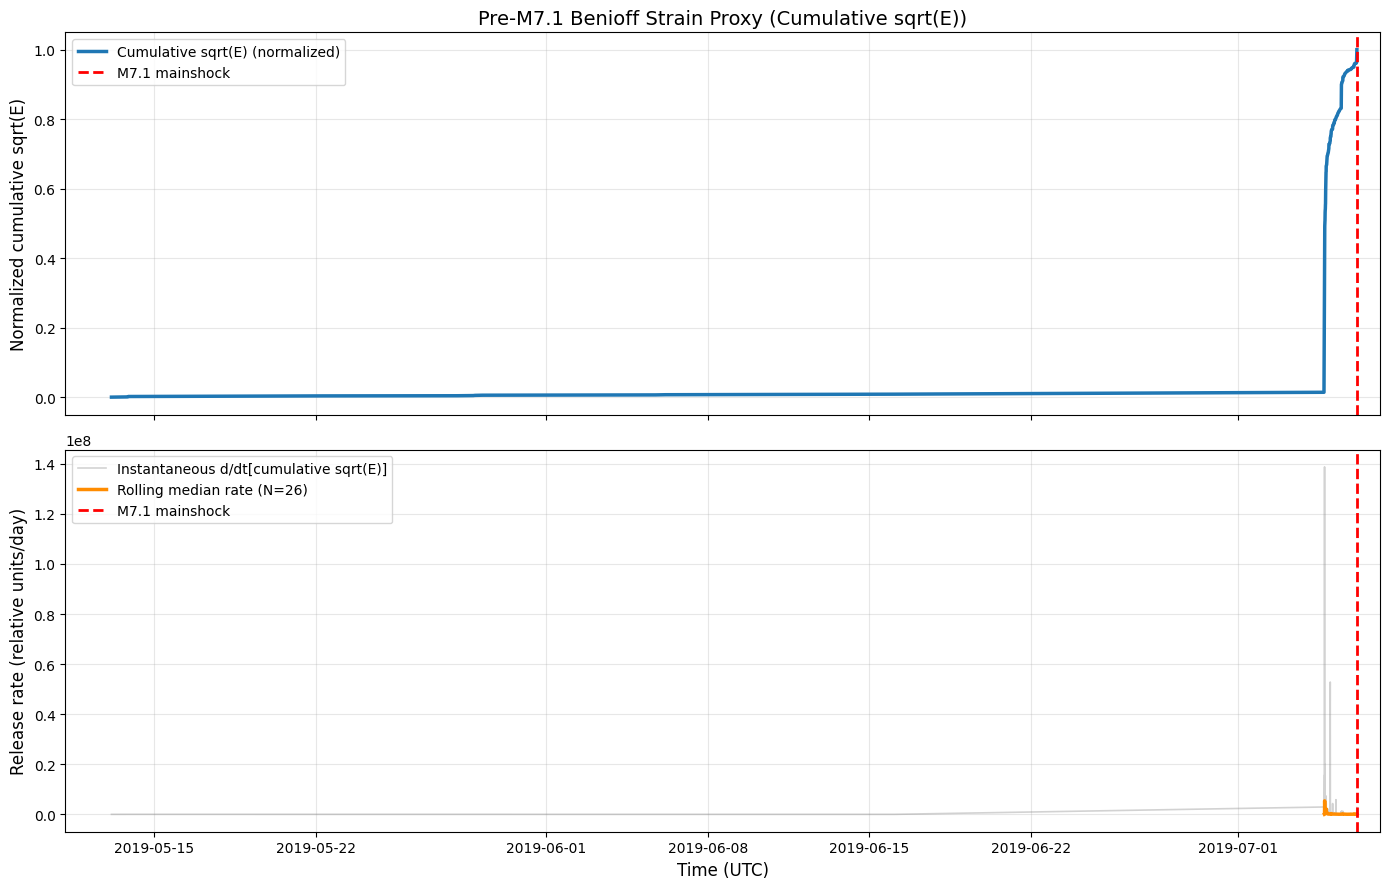

Events analyzed: 312
Time span: 2019-05-13 03:23:27.720000+00:00 to 2019-07-06 03:17:13.500000+00:00
Quadratic acceleration coefficient a: 1.685e+02
Interpretation: accelerating cumulative sqrt(E) before M7.1 (possible precursor).


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Seismic energy release precursor test (Benioff strain proxy) ---
# E ~ 10^(1.5M), so sqrt(E) ~ 10^(0.75M)
ridge_lat, ridge_lon = 35.77, -117.60
radius_km = 80.0
mc_local = 2.5
weeks_back = 8
m71_time = pd.Timestamp('2019-07-06 03:19:53', tz='UTC')
start_time = m71_time - pd.Timedelta(weeks=weeks_back)

cat = df.copy()
cat['time'] = pd.to_datetime(cat['time'], errors='coerce', utc=True)
for col in ['mag', 'latitude', 'longitude']:
    cat[col] = pd.to_numeric(cat[col], errors='coerce')
cat = cat.dropna(subset=['time', 'mag', 'latitude', 'longitude']).copy()

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1r = np.radians(lat1)
    lon1r = np.radians(lon1)
    lat2r = np.radians(np.asarray(lat2, dtype=float))
    lon2r = np.radians(np.asarray(lon2, dtype=float))
    dlat = lat2r - lat1r
    dlon = lon2r - lon1r
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon / 2.0) ** 2
    return R * 2.0 * np.arcsin(np.sqrt(a))

cat['dist_to_m71_km'] = haversine_km(ridge_lat, ridge_lon, cat['latitude'].values, cat['longitude'].values)

foreshocks_e = cat[
    (cat['time'] >= start_time)
    & (cat['time'] < m71_time)
    & (cat['mag'] >= mc_local)
    & (cat['dist_to_m71_km'] <= radius_km)
].sort_values('time').reset_index(drop=True)

if len(foreshocks_e) < 20:
    raise ValueError(f'Only {len(foreshocks_e)} events in window; increase radius or lower Mc.')

# Energy proxy and Benioff strain (relative units)
foreshocks_e['energy_rel'] = 10 ** (1.5 * foreshocks_e['mag'])
foreshocks_e['sqrt_energy_rel'] = 10 ** (0.75 * foreshocks_e['mag'])
foreshocks_e['cum_sqrt_energy'] = foreshocks_e['sqrt_energy_rel'].cumsum()

# Normalize cumulative curve for shape-focused visualization
foreshocks_e['cum_sqrt_energy_norm'] = foreshocks_e['cum_sqrt_energy'] / foreshocks_e['cum_sqrt_energy'].iloc[-1]

# Event-time acceleration diagnostic: slope of cumulative curve
t_days = (foreshocks_e['time'] - foreshocks_e['time'].min()).dt.total_seconds() / 86400.0
cum_vals = foreshocks_e['cum_sqrt_energy'].values

# Quadratic fit C(t) = a t^2 + b t + c; a > 0 suggests acceleration
a2, b1, c0 = np.polyfit(t_days, cum_vals, 2)

# Local slope (dC/dt) in relative units/day using finite differences
local_rate = np.gradient(cum_vals, t_days)
foreshocks_e['cum_rate'] = local_rate
rate_win = min(30, max(8, len(foreshocks_e) // 12))
foreshocks_e['cum_rate_smooth'] = foreshocks_e['cum_rate'].rolling(rate_win, min_periods=max(3, rate_win // 2)).median()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
ax1, ax2 = axes

# Panel 1: cumulative sqrt(E)
ax1.plot(
    foreshocks_e['time'],
    foreshocks_e['cum_sqrt_energy_norm'],
    color='tab:blue',
    lw=2.5,
    label='Cumulative sqrt(E) (normalized)'
)
ax1.axvline(m71_time, color='red', linestyle='--', lw=2, label='M7.1 mainshock')
ax1.set_ylabel('Normalized cumulative sqrt(E)', fontsize=12)
ax1.set_title('Pre-M7.1 Benioff Strain Proxy (Cumulative sqrt(E))', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# Panel 2: rate of cumulative release (acceleration indicator)
ax2.plot(
    foreshocks_e['time'],
    foreshocks_e['cum_rate'],
    color='gray',
    alpha=0.35,
    lw=1.2,
    label='Instantaneous d/dt[cumulative sqrt(E)]'
)
ax2.plot(
    foreshocks_e['time'],
    foreshocks_e['cum_rate_smooth'],
    color='darkorange',
    lw=2.5,
    label=f'Rolling median rate (N={rate_win})'
)
ax2.axvline(m71_time, color='red', linestyle='--', lw=2, label='M7.1 mainshock')
ax2.set_ylabel('Release rate (relative units/day)', fontsize=12)
ax2.set_xlabel('Time (UTC)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

plt.xlim(start_time, m71_time + pd.Timedelta(days=1))
plt.tight_layout()
plt.savefig('foreshock_energy_release.png', dpi=300)
plt.show()

print(f'Events analyzed: {len(foreshocks_e)}')
print(f'Time span: {foreshocks_e["time"].min()} to {foreshocks_e["time"].max()}')
print(f'Quadratic acceleration coefficient a: {a2:.3e}')
if a2 > 0:
    print('Interpretation: accelerating cumulative sqrt(E) before M7.1 (possible precursor).')
else:
    print('Interpretation: no acceleration in cumulative sqrt(E) for this window.')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30834 entries, 0 to 30833
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             30834 non-null  object 
 1   latitude         30834 non-null  float64
 2   longitude        30834 non-null  float64
 3   depth            30834 non-null  float64
 4   mag              30834 non-null  float64
 5   magType          30833 non-null  object 
 6   nst              30750 non-null  float64
 7   gap              30831 non-null  float64
 8   dmin             30423 non-null  float64
 9   rms              30791 non-null  float64
 10  net              30834 non-null  object 
 11  id               30834 non-null  object 
 12  updated          30834 non-null  object 
 13  place            30834 non-null  object 
 14  type             30834 non-null  object 
 15  horizontalError  26007 non-null  float64
 16  depthError       30771 non-null  float64
 17  magError    

In [57]:
len(df[df['mag'] >= 4])

999

# Omori fit

In [58]:
# Step 6: Omori's law fit for aftershocks
import numpy as np
import matplotlib.pyplot as plt

after_eq = mainshock_window[mainshock_window['days_from_main'] > 0].copy()
if after_eq.empty:
    print('No aftershocks in the ±30 day window.')
else:
    after_eq['day_bin'] = np.floor(after_eq['days_from_main']).astype(int)
    after_counts = after_eq.groupby('day_bin').size().reindex(range(1, 31), fill_value=0)

    # times (t) and rates n(t)
    t = after_counts.index.values.astype(float)
    n = after_counts.values.astype(float)

    # Small positive times only (exclude zeros at t very small if catalog incomplete)
    mask_pos = (t > 0)
    t_fit = t[mask_pos]
    n_fit = n[mask_pos]

    # Omori function K/(c+t)^p
    def omori_func(t, K, c, p):
        return K / ((c + t) ** p)

    try:
        from scipy.optimize import curve_fit
        popt, pcov = curve_fit(omori_func, t_fit, n_fit, p0=[n_fit.max(), 0.1, 1.0], bounds=(0, np.inf), maxfev=10000)
        K_fit, c_fit, p_fit = popt
        print(f'Omori fit: K={K_fit:.3g}, c={c_fit:.3g}, p={p_fit:.3f}')
        n_model = omori_func(t, K_fit, c_fit, p_fit)
    except Exception as e:
        print('SciPy curve_fit unavailable or fit failed; falling back to a log-log linear approximation:', e)
        # Fallback: fit log(n) = A - p * log(t+c); choose c small (0.1)
        c_guess = 0.1
        with np.errstate(divide='ignore'):
            logt = np.log(t_fit + c_guess)
            logn = np.log(np.where(n_fit>0, n_fit, np.nan))
        mask_valid = np.isfinite(logn)
        if mask_valid.sum() >= 2:
            slope, intercept = np.polyfit(logt[mask_valid], logn[mask_valid], 1)
            p_fit = -slope
            K_fit = np.exp(intercept) * (c_guess ** p_fit)
            c_fit = c_guess
            n_model = omori_func(t, K_fit, c_fit, p_fit)
            print(f'Fallback Omori approx: K={K_fit:.3g}, c={c_fit:.3g}, p={p_fit:.3f}')
        else:
            print('Not enough non-zero aftershock bins for a reliable fit.')
            n_model = np.full_like(n, np.nan)

    # Plot on log-log
    fig, ax = plt.subplots(figsize=(7,4))
    ax.scatter(t, n, label='Observed (daily)', color='steelblue')
    ax.plot(t, n_model, 'r--', label=f'Omori model (p={p_fit:.2f})')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Days after mainshock (log scale)')
    ax.set_ylabel('Aftershocks per day (log scale)')
    ax.set_title('Aftershock decay and Omori fit')
    ax.legend()
    ax.grid(True, which='both', ls=':', alpha=0.4)
    plt.tight_layout()
    plt.savefig('omori_fit.png', dpi=300)
    plt.show()

    print('\nCaveats:')
    print('- Fit depends strongly on chosen time window and catalog completeness near t→0.')
    print('- If p~1 this is typical; p significantly different may signal catalog or physical differences.')

NameError: name 'mainshock_window' is not defined